In [1]:
#@title Paquetes necesarios --------------------------------------------------------------------------------------------------------------------------------------------------------------
from math import *
from pylab import *
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import time
from scipy.signal import argrelextrema
from scipy.fft import fft, ifft
from scipy.optimize import fsolve
from scipy.integrate import odeint


import matplotlib as mpl
import matplotlib.lines as mlines

from scipy.signal import find_peaks

from mpl_toolkits.mplot3d import Axes3D #para graficar en 3D


In [2]:
#@title Funciones y parámetros (numba)

import numpy as np
from numba import njit

# =========================
# Funciones auxiliares
# =========================

@njit
def minf(v):
    return 1.0 / (1.0 + np.exp(-(v + 40.0) / 9.0))

@njit
def hinf(v):
    return 1.0 / (1.0 + np.exp((v + 62.0) / 10.0))

@njit
def ninf(v):
    return 1.0 / (1.0 + np.exp(-(v + 53.0) / 16.0))

@njit
def taum(v):
    return 0.3 + 1e-12 * v

@njit
def tauh(v):
    return 1.0 + 11.0 / (1.0 + np.exp((v + 62.0) / 10.0))

@njit
def taun(v):
    return 1.0 + 6.0 / (1.0 + np.exp((v + 53.0) / 16.0))

#expresion equivalente al original [ 0.5 * (1.0 + np.tanh(v / 4.0)) ]
@njit
def sinf(v):
    return 1.0 / (1.0 + np.exp(-v / 2.0))
# =========================
# Parámetros (como floats)
# =========================

C = 1.0
El = -65.0
Ena = 55.0
Ek = -75.0
Gl = 0.025
Gna = 120.0
Gk = 36.0
Ein = -80.0
Gself = 0.08
G12 = 0.08
G21 = 0.08

taurse_i = 0.3
taudec_i = 9.0

alpha = 0.85


# =========================
# Corriente iónica
# =========================

@njit
def Fa(v, n, Iapp):
    return (
        Iapp
        - Gl * (v - El)
        - Gna * (minf(v) ** 3) * (alpha - n) * (v - Ena)
        - Gk * (n ** 4) * (v - Ek)
    )


# =========================
# RK2 (sin crear arrays extra)
# =========================

@njit
def rk2_step_reduced(state, dt, Iapp):
    V, n, S = state

    # k1
    dV1 = (Fa(V, n, Iapp) - Gself * S * (V - Ein)) / C
    dn1 = (ninf(V) - n) / taun(V)
    dS1 = sinf(V) * (1.0 - S) / taurse_i - S / taudec_i

    # estado intermedio
    V2 = V + dt * dV1
    n2 = n + dt * dn1
    S2 = S + dt * dS1

    # k2
    dV2 = (Fa(V2, n2, Iapp) - Gself * S2 * (V2 - Ein)) / C
    dn2 = (ninf(V2) - n2) / taun(V2)
    dS2 = sinf(V2) * (1.0 - S2) / taurse_i - S2 / taudec_i

    # actualización
    state[0] = V + 0.5 * dt * (dV1 + dV2)
    state[1] = n + 0.5 * dt * (dn1 + dn2)
    state[2] = S + 0.5 * dt * (dS1 + dS2)

    return state


# =========================
# Red de 2 nodos
# =========================
@njit
def rk2_step_net(state, dt, Iapp):
    V1, n1, S1, V2, n2, S2 = state

    # k1
    dV1 = (Fa(V1, n1, Iapp) - G21 * S2 * (V1 - Ein)) / C
    dn1 = (ninf(V1) - n1) / taun(V1)
    dS1 = sinf(V1) * (1.0 - S1) / taurse_i - S1 / taudec_i

    dV2 = (Fa(V2, n2, Iapp) - G12 * S1 * (V2 - Ein)) / C
    dn2 = (ninf(V2) - n2) / taun(V2)
    dS2 = sinf(V2) * (1.0 - S2) / taurse_i - S2 / taudec_i

    # estado intermedio
    V1_ = V1 + dt * dV1
    n1_ = n1 + dt * dn1
    S1_ = S1 + dt * dS1

    V2_ = V2 + dt * dV2
    n2_ = n2 + dt * dn2
    S2_ = S2 + dt * dS2

    # k2
    dV1_ = (Fa(V1_, n1_, Iapp) - G21 * S2_ * (V1_ - Ein)) / C
    dn1_ = (ninf(V1_) - n1_) / taun(V1_)
    dS1_ = sinf(V1_) * (1.0 - S1_) / taurse_i - S1_ / taudec_i

    dV2_ = (Fa(V2_, n2_, Iapp) - G12 * S1_ * (V2_ - Ein)) / C
    dn2_ = (ninf(V2_) - n2_) / taun(V2_)
    dS2_ = sinf(V2_) * (1.0 - S2_) / taurse_i - S2_ / taudec_i

    # actualización
    state[0] = V1 + 0.5 * dt * (dV1 + dV1_)
    state[1] = n1 + 0.5 * dt * (dn1 + dn1_)
    state[2] = S1 + 0.5 * dt * (dS1 + dS1_)

    state[3] = V2 + 0.5 * dt * (dV2 + dV2_)
    state[4] = n2 + 0.5 * dt * (dn2 + dn2_)
    state[5] = S2 + 0.5 * dt * (dS2 + dS2_)

    return state

# ========================
# Función de paralelizacion
# =========================

from numba import prange

@njit(parallel=True)
def simulate_all(Y_redes, V1_0,n1_0,s1_0,V2_0,n2_0,s2_0, dt, Iapp):
    nets_num, N, _ = Y_redes.shape

    for j in prange(nets_num):
        Y_redes[j,0,0] = V1_0[j]
        Y_redes[j,0,1] = n1_0[j]
        Y_redes[j,0,2] = s1_0[j]
        Y_redes[j,0,3] = V2_0[j]
        Y_redes[j,0,4] = n2_0[j]
        Y_redes[j,0,5] = s2_0[j]

        state = np.empty(6)
        state[:] = Y_redes[j,0,:]

        for i in range(1, N):
            rk2_step_net(state, dt, Iapp)
            Y_redes[j,i,:] = state

# =====================================================
# Función de Paralelizacion Mínima (solo guardo V1 y V2)
# =====================================================
@njit(parallel=True)
def simulate_all_min(Y_redes, V1_0,n1_0,s1_0,V2_0,n2_0,s2_0, dt, Iapp):
    nets_num, N, _ = Y_redes.shape

    for j in prange(nets_num):
        state = np.empty(6)
        state[0] = V1_0[j]
        state[1] = n1_0[j]
        state[2] = s1_0[j]
        state[3] = V2_0[j]
        state[4] = n2_0[j]
        state[5] = s2_0[j]
        # guardar estado inicial
        Y_redes[j,0,0] = state[0]
        Y_redes[j,0,1] = state[3]
        #integrar
        for i in range(1, N):
            rk2_step_net(state, dt, Iapp)
            Y_redes[j,i,0] = state[0]
            Y_redes[j,i,1] = state[3]

In [3]:
#@title FUNCION de extracción del código del transitorio

def cod_tran(signal):
  max,_ = find_peaks(signal, height=-20)
  max = max[1:]  #quito el primer maximo (suele ser transitorio)
  min_index = min(np.diff(max)) #minimo espacio entre spikes
  """"""
  max_init = []   #indice que inicia cada "burst"
  count = []      #conteo
  i=0
  """rutina de conteo"""
  while i<len(max)-1:
    max_init.append(max[i])
    k_aux = 1
    j = i
    while max[j+1]-max[j]<=1.1*min_index:
      k_aux += 1
      j += 1
      if j == len(max)-1:
        break
    count.append(k_aux)
    i = j+1
  #corte - si el conteo supero cierto umbral (en tal caso, simular mas tiempo)
  corte2 = True
  if corte2 is True:
    if count[-1]>30:
      count = count[:-1]
      print('corte por umbral!')
  return count, max, max_init





In [4]:
#@title FUNCION de extracción del código del transitorio (corregida)

def cod_tran(signal):
  max_idx, _ = find_peaks(signal, height=-20)
  
  # --- ÚNICO CAMBIO: Validación de seguridad ---
  if len(max_idx) < 3: 
    # Si hay 0, 1 o 2 picos, no podemos calcular min(np.diff)
    return [], [], []
  # ---------------------------------------------

  max_v = max_idx[1:]  # quito el primer maximo
  min_index = min(np.diff(max_v)) 
  
  max_init = []   
  count = []      
  i = 0
  
  """rutina de conteo"""
  while i < len(max_v) - 1:
    max_init.append(max_v[i])
    k_aux = 1
    j = i
    # Agregamos j+1 < len(max_v) para evitar que se pase del índice
    while j+1 < len(max_v) and max_v[j+1] - max_v[j] <= 1.1 * min_index:
      k_aux += 1
      j += 1
      if j == len(max_v) - 1:
        break
    count.append(k_aux)
    i = j + 1
    
  # corte - si el conteo supero cierto umbral
  corte2 = True
  if corte2 is True and len(count) > 0:
    if count[-1] > 30:
      count = count[:-1]
      print('corte por umbral!')
      
  return count, max_v, max_init

## Simulacion red

### Simulación básica

In [ ]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 15000.0
dt = 0.001
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.3

"""inicializacion de variables"""
Y_red = np.empty((N, 6), dtype=np.float64)
Y_red[0,:] = [-90.,0.1,0.1,-65.0,0.2,0.0]

#integracion
state = np.empty(6)
state[:] = Y_red[0,:]
for i in range(1, N):
    rk2_step_net(state, dt, Iapp)   # modifica state
    Y_red[i,:] = state



In [ ]:
#@title distintos plot
# ------------ Series Temporales  -----------
fig = plt.figure(figsize=(14,6))
ax = fig.add_subplot(111)
ax.set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s$'%(Iapp,G12), loc='left', fontsize=14)
##
ax.plot(t,Y_red[:,0], linewidth=1, label = 'Nodo 1')
ax.plot(t,Y_red[:,3], ls = '--',linewidth=1, label = 'Nodo 2')
###
ax.legend(fontsize = 14, loc='upper left', frameon = False, ncols = 2, bbox_to_anchor=(0.6, 1.2))
ax.set_xlabel('Tiempo (ms)', fontsize=12)
ax.set_ylabel('V [mV]', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(1000,2000)
#
plt.tight_layout()
#

# ----------- Proyecciones ------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
ax.set_title('$G_{12}=G_{21}$=%s'%(Gself), loc='center', fontsize=14)
##
ax.plot(Y_red[:,0],Y_red[:,1], linewidth=1, label = 'Nodo 1')
ax.plot(Y_red[:,3],Y_red[:,4],linewidth=1, label = 'Nodo 2')
###
ax.set_xlabel('V [mV]', fontsize=12)
ax.set_ylabel('n', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#
plt.tight_layout()
#

# ----------- V1 vs V2 --------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
##
ax.plot(Y_red[:,0],Y_red[:,3], linewidth=1)
identity = np.arange(-80,65,1)
ax.plot(identity,identity, ls = '--', c= 'tomato')
###
ax.set_xlabel('$V_1$ [mV]', fontsize=12)
ax.set_ylabel('$V_2$ [mV]', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#escala de ejes
ax.set_aspect('equal', adjustable='box')
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_major_locator(MultipleLocator(20))
#
plt.tight_layout()
#
plt.show()
plt.close()


### Análisis de transitorios

In [ ]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.01#25


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

end = time.time()
print('duración (segundos) de la simulación',end - start)

print('====================')
print('condiciones iniciales')
print('====================')
for i in range(nets_num):
  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


In [ ]:
#@title resimulacion con distintos dt
k = 2

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


### Resimulación de un trial particular

In [ ]:
#@title resimulacion con distintos dt
k = 2

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


In [ ]:
#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#

## Simulación con distintos valores de Iapp

### Iapp = 2.0

trial 3 estado inicial: [-70, np.float64(0.08891092383602917), np.float64(0.0801241891785539), -65, np.float64(0.8191959946495607), np.float64(0.8452238688130184)]
duración (segundos) de la simulación 34.41588234901428


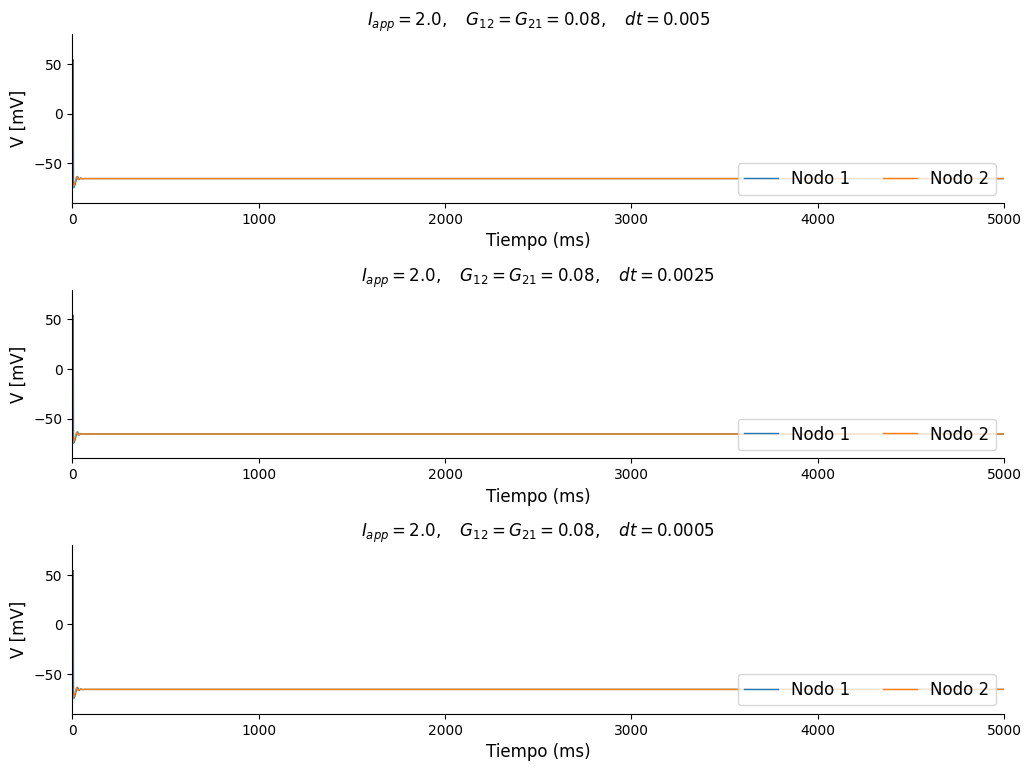

In [43]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.0


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 2.1

trial 3 estado inicial: [-70, np.float64(0.29372639335997375), np.float64(0.7406893925523093), -65, np.float64(0.5942586895203702), np.float64(0.6614604999694791)]
duración (segundos) de la simulación 34.632018089294434


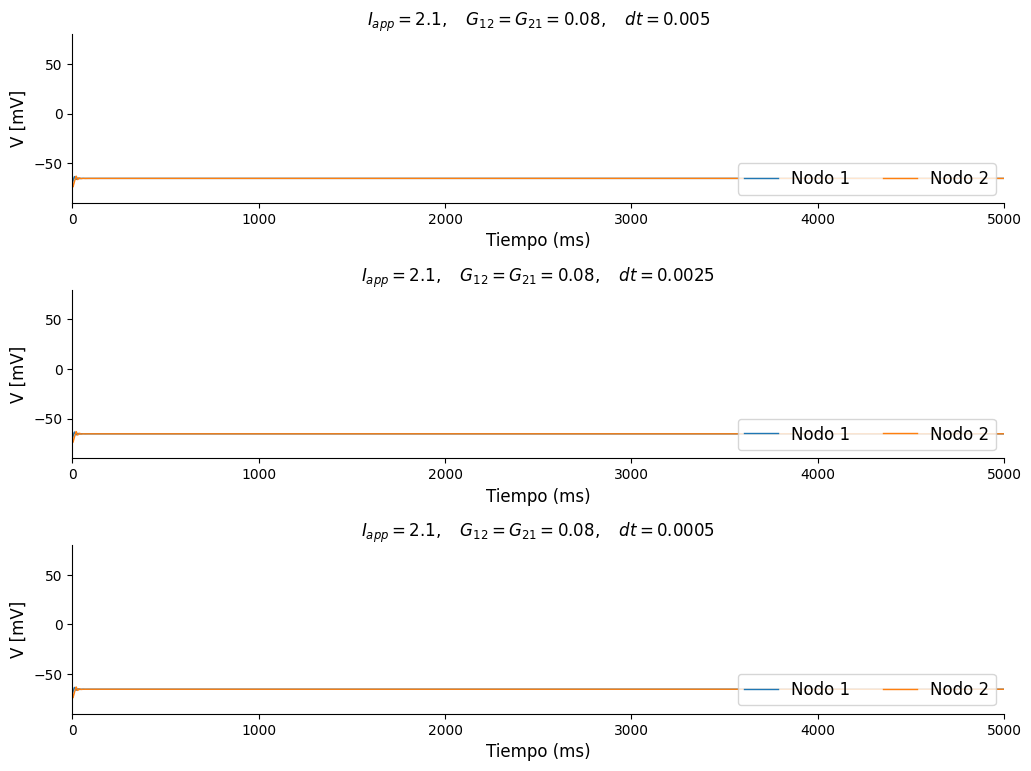

In [9]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.1


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 2.2

trial 3 estado inicial: [-70, np.float64(0.9231316107212821), np.float64(0.1940296925670808), -65, np.float64(0.6164205508082117), np.float64(0.7944864992149334)]
duración (segundos) de la simulación 38.34648823738098


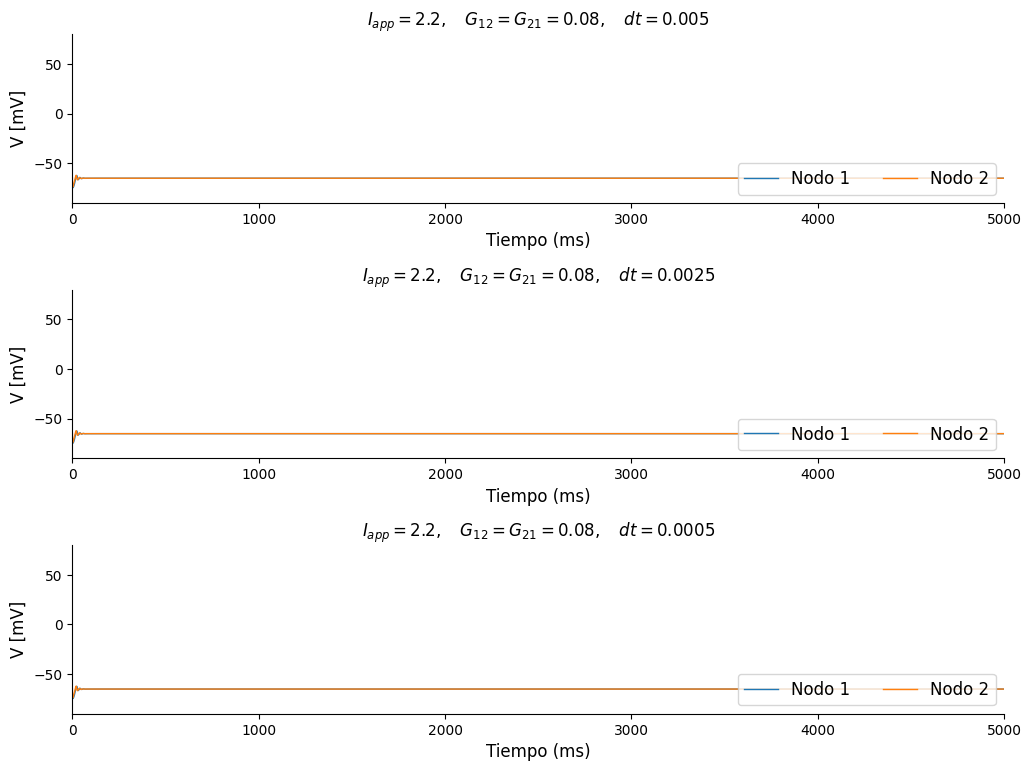

In [8]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.2


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 2.3

trial 3 estado inicial: [-70, np.float64(0.3972533083228137), np.float64(0.8719495023806689), -65, np.float64(0.573808084472319), np.float64(0.46549410349590714)]
duración (segundos) de la simulación 35.76494574546814


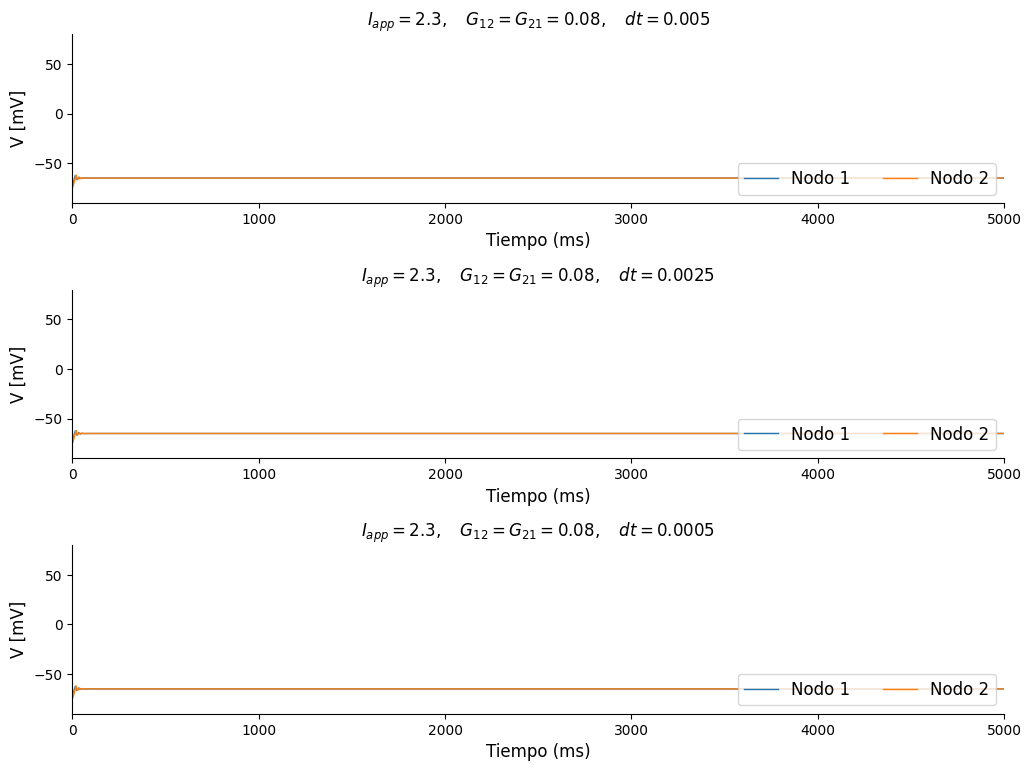

In [7]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.3


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 2.4

trial 3 estado inicial: [-70, np.float64(0.5656901081376878), np.float64(0.25153320387617395), -65, np.float64(0.6619769409403116), np.float64(0.6374861356539657)]
duración (segundos) de la simulación 50.54476523399353
corte por umbral!
corte por umbral!
corte por umbral!


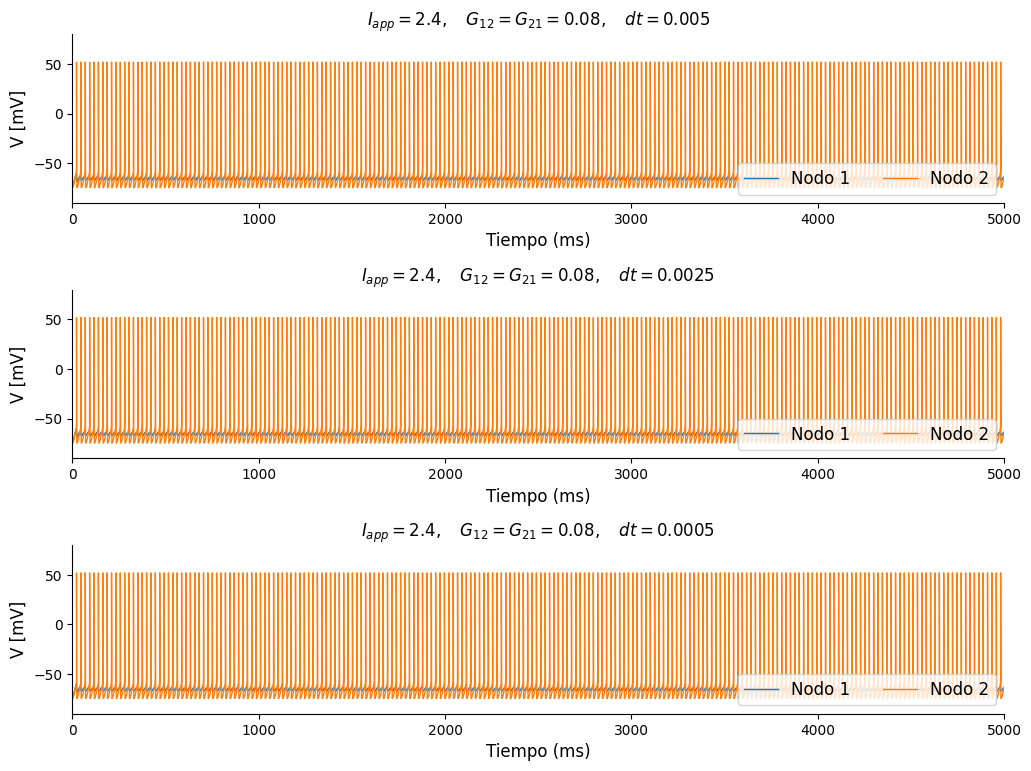

In [52]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.4


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp=2.5

trial 3 estado inicial: [-70, np.float64(0.22092638395084663), np.float64(0.7384184703924418), -65, np.float64(0.0023252669241486945), np.float64(0.8247685794089109)]
duración (segundos) de la simulación 34.41529870033264
corte por umbral!
corte por umbral!
corte por umbral!


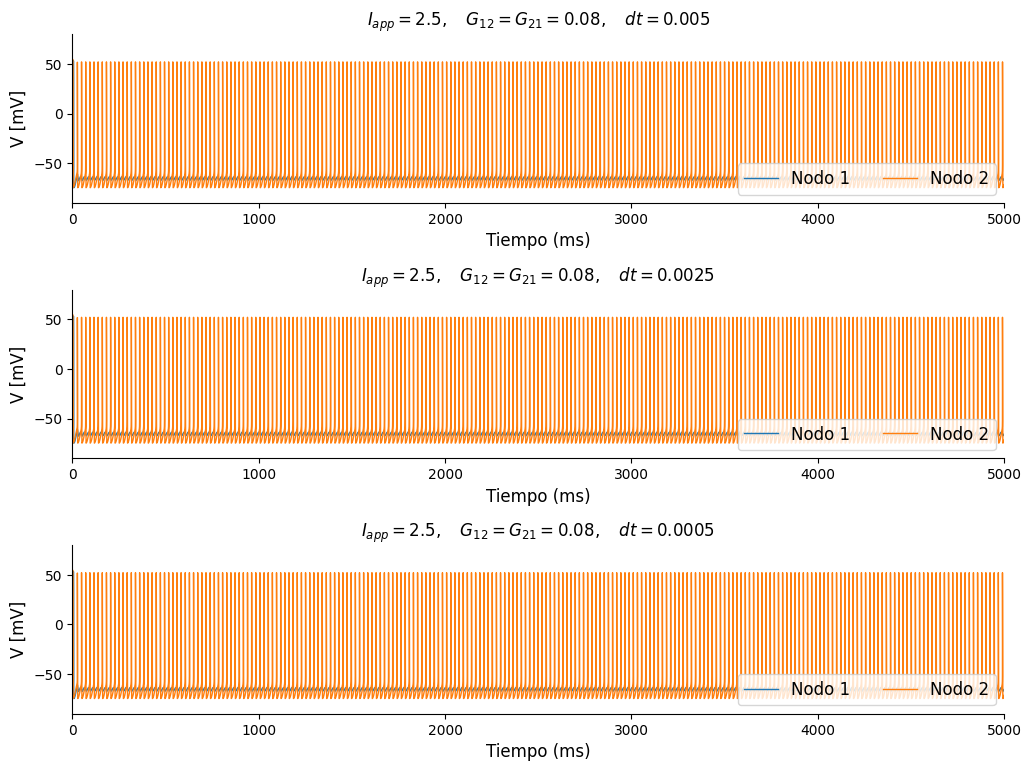

In [44]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.5


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp= 2.6


trial 3 estado inicial: [-70, np.float64(0.3909635843590943), np.float64(0.9229770347530383), -65, np.float64(0.3888187181857705), np.float64(0.6679693705229727)]
duración (segundos) de la simulación 35.184600591659546
corte por umbral!
corte por umbral!
corte por umbral!


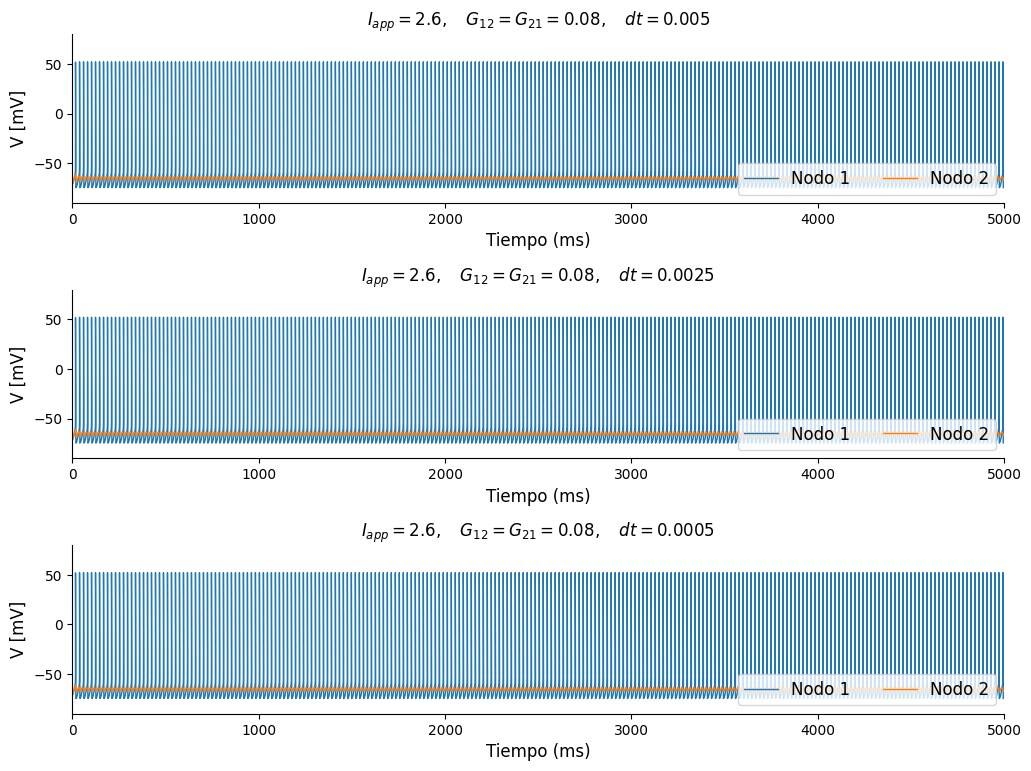

In [45]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.6


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp=2.7

trial 3 estado inicial: [-70, np.float64(0.8518926729618609), np.float64(0.7715381020773638), -65, np.float64(0.10156472373005165), np.float64(0.6837931406734558)]
duración (segundos) de la simulación 33.51022696495056
corte por umbral!
corte por umbral!
corte por umbral!


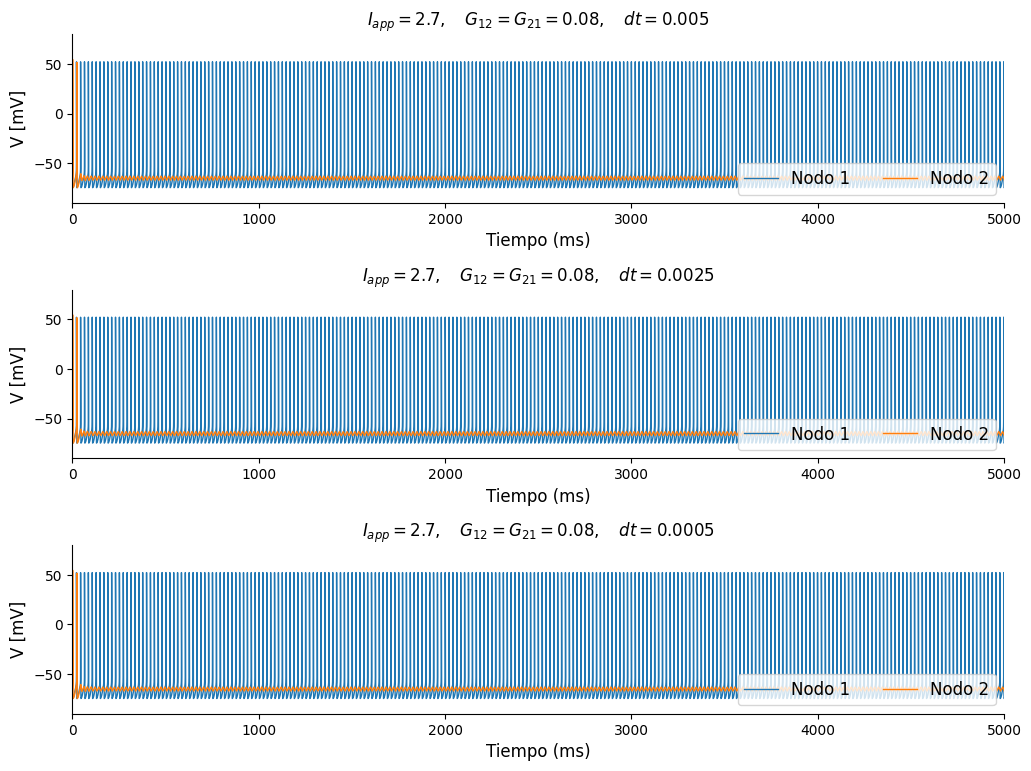

In [46]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.7


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 2.75

trial 3 estado inicial: [-70, np.float64(0.10618856653078801), np.float64(0.8837907672736909), -65, np.float64(0.7581136639215974), np.float64(0.7222576812021636)]
duración (segundos) de la simulación 88.59154081344604
corte por umbral!
corte por umbral!
corte por umbral!


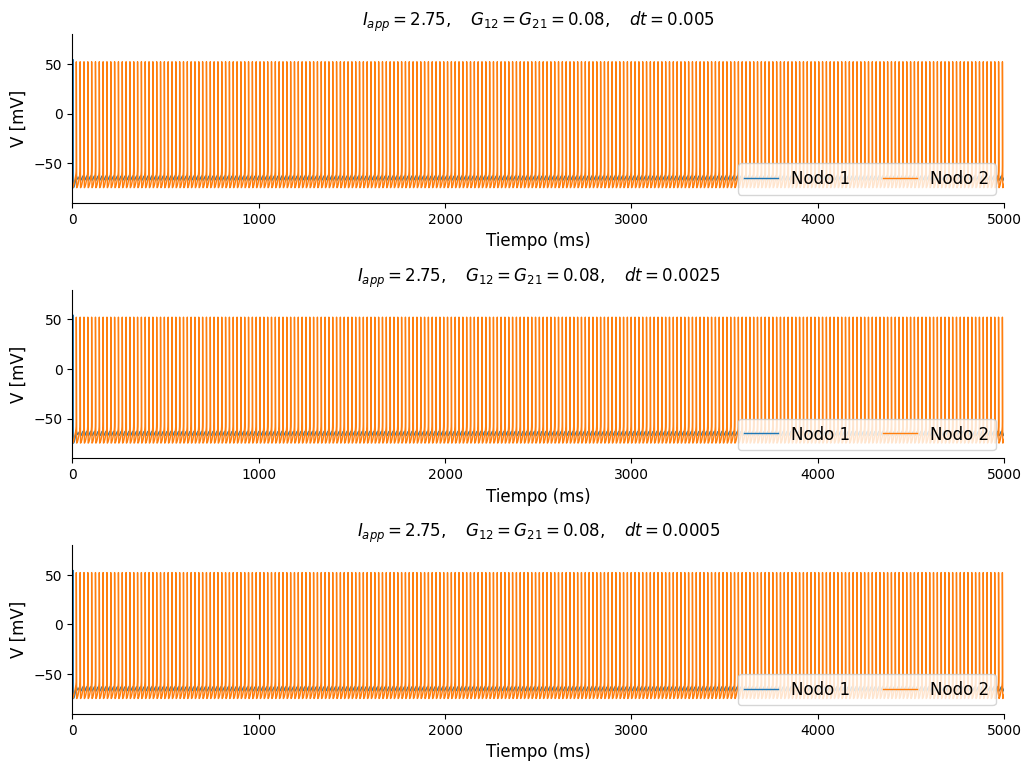

In [53]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.75


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 2.8

trial 3 estado inicial: [-70, np.float64(0.5641848324321168), np.float64(0.20670885443629616), -65, np.float64(0.3137132774688033), np.float64(0.06942905964681079)]
duración (segundos) de la simulación 34.24997901916504
corte por umbral!
corte por umbral!
corte por umbral!


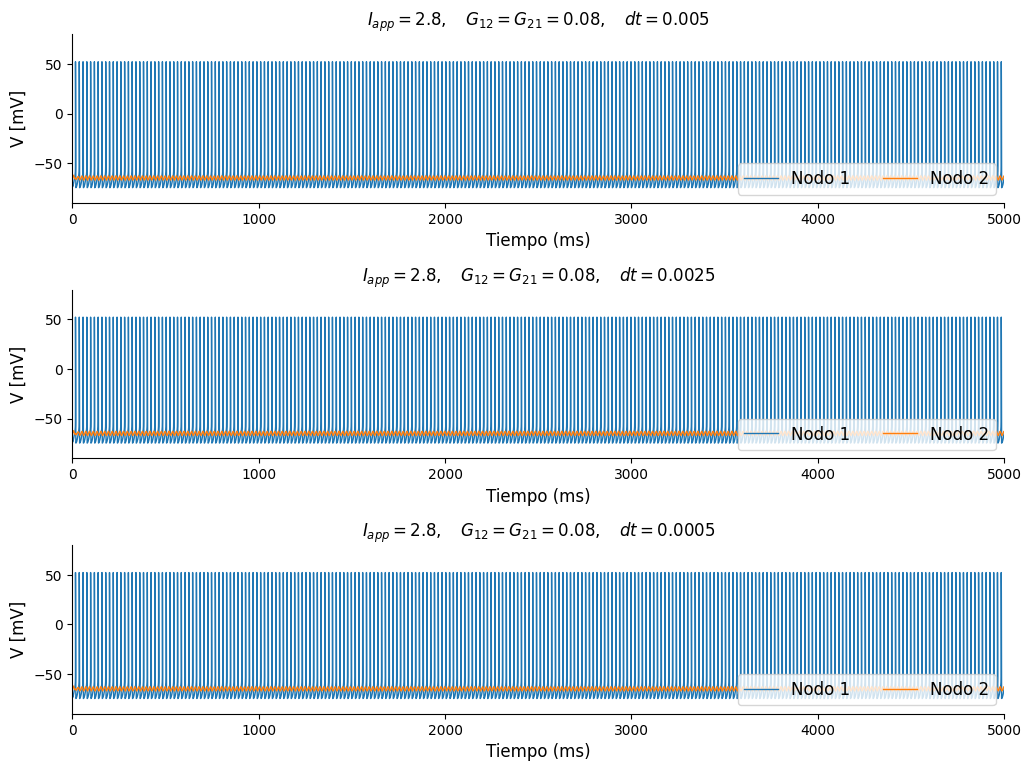

In [10]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.8


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 2.9

trial 3 estado inicial: [-70, np.float64(0.3666500091812549), np.float64(0.6167452275200734), -65, np.float64(0.15857540269421), np.float64(0.05904757088467949)]
duración (segundos) de la simulación 36.086928844451904
corte por umbral!
corte por umbral!
corte por umbral!


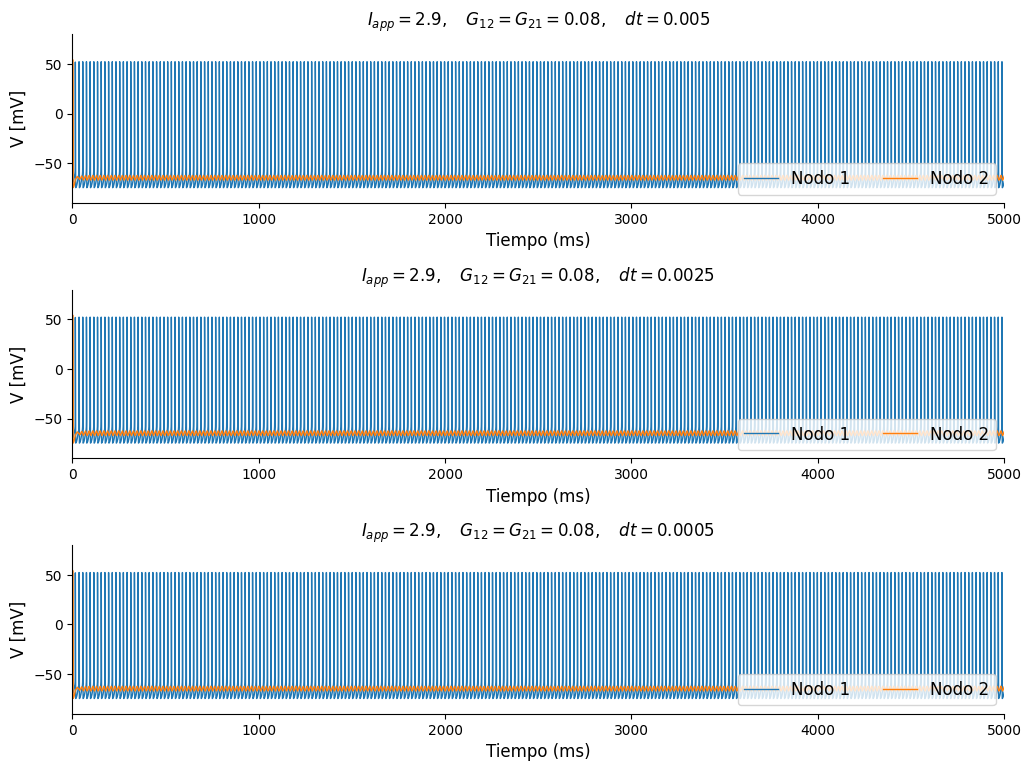

In [48]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.9


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3

trial 3 estado inicial: [-70, np.float64(0.7204051814800847), np.float64(0.12858608245456016), -65, np.float64(0.8776222386461795), np.float64(0.7540833412326756)]
duración (segundos) de la simulación 34.441142082214355
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


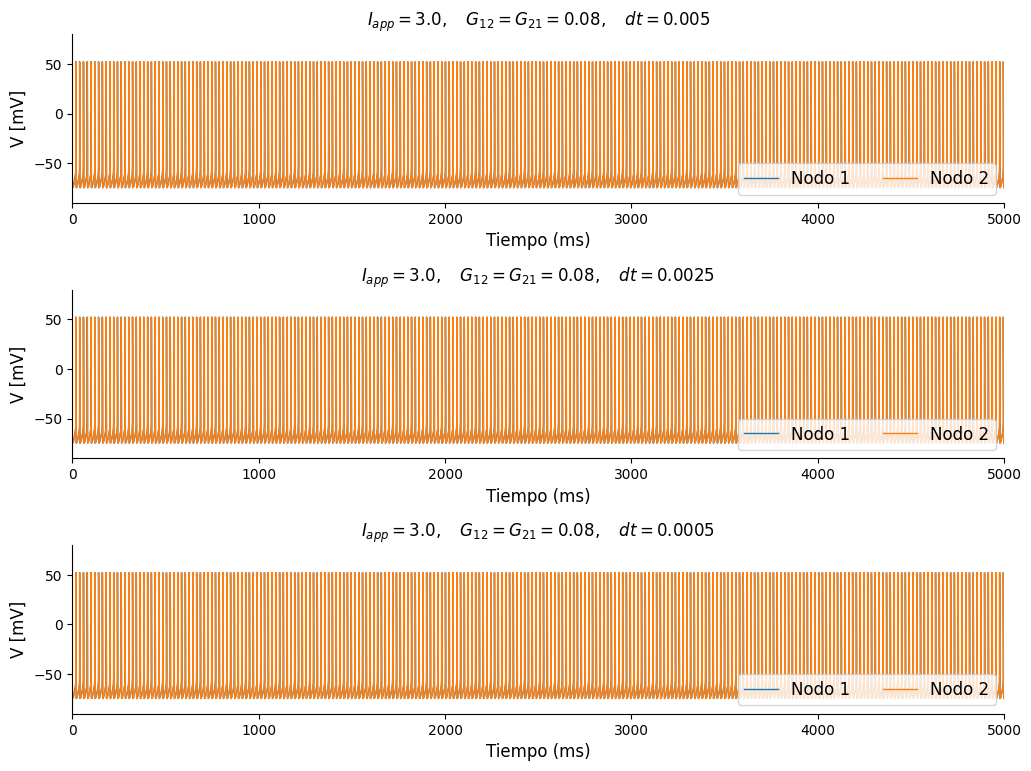

In [49]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.0


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.1

trial 3 estado inicial: [-70, np.float64(0.289796040642582), np.float64(0.25930388328225107), -65, np.float64(0.6170482885310147), np.float64(0.8500983918095836)]
duración (segundos) de la simulación 55.40430665016174
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


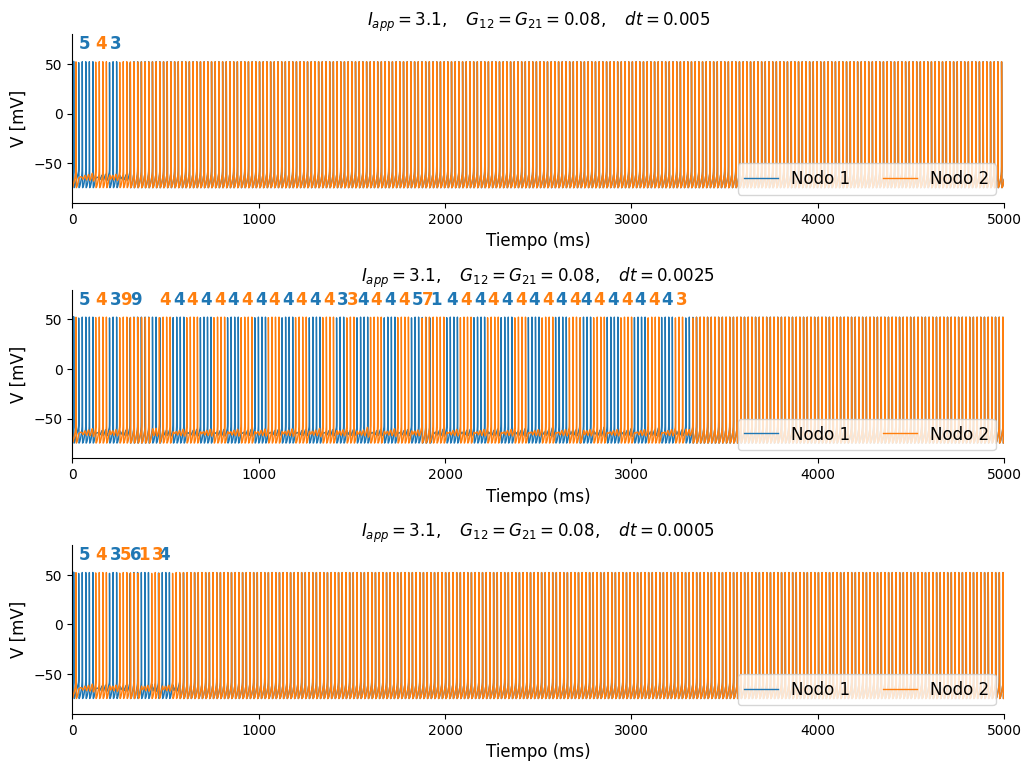

In [50]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.1


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.2

trial 3 estado inicial: [-70, np.float64(0.6919160494903807), np.float64(0.9453394258229556), -65, np.float64(0.319514306359433), np.float64(0.791565021683369)]
duración (segundos) de la simulación 34.03667974472046
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


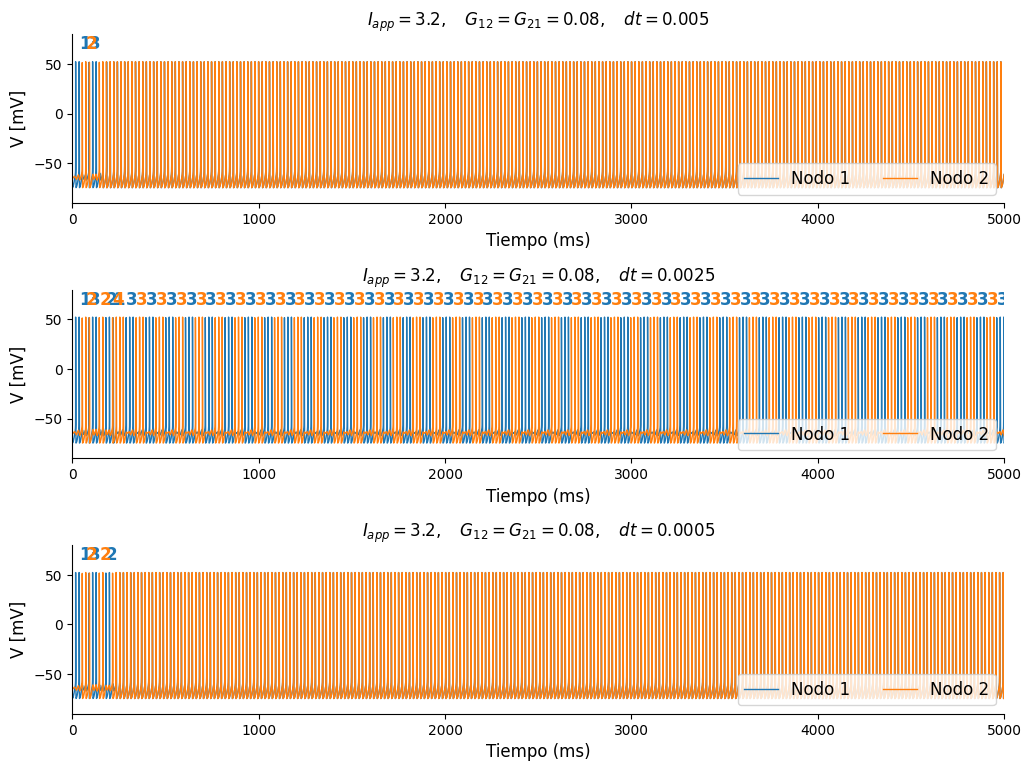

In [11]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.2


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.3

trial 3 estado inicial: [-70, np.float64(0.19627658331285358), np.float64(0.684331951708082), -65, np.float64(0.4936234515631792), np.float64(0.97215188128835)]
duración (segundos) de la simulación 31.65702486038208
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


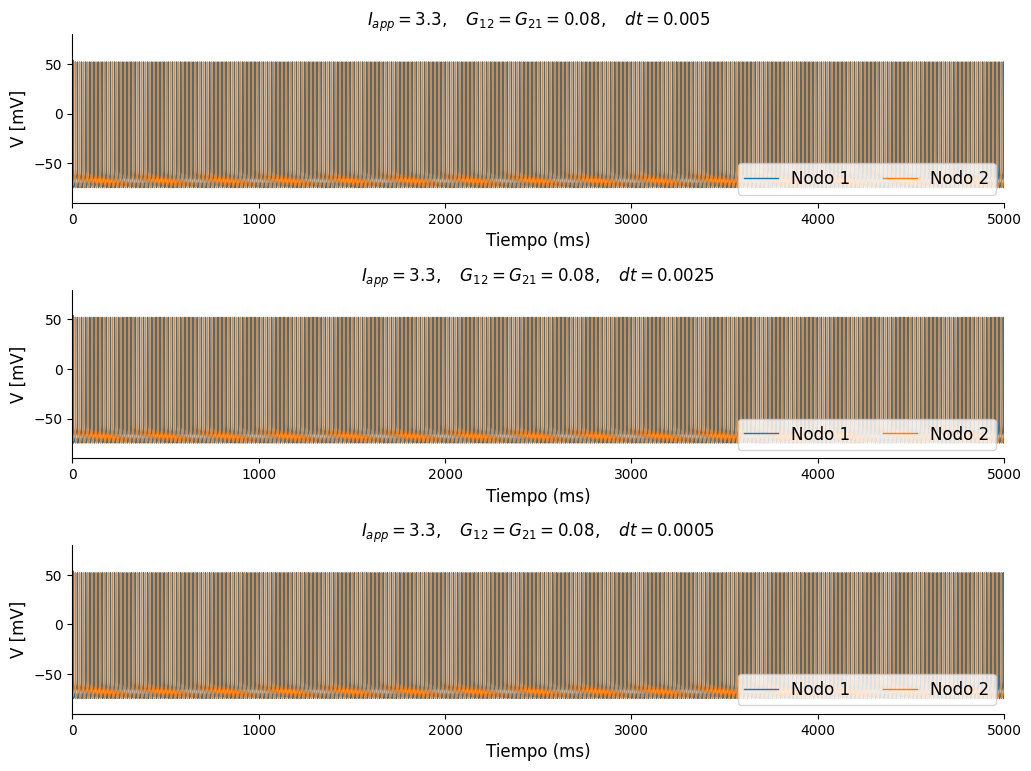

In [12]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.3


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.4

trial 3 estado inicial: [-70, np.float64(0.11074190930607908), np.float64(0.5089264724274882), -65, np.float64(0.6215988256857418), np.float64(0.4722128015529963)]
duración (segundos) de la simulación 31.358159065246582


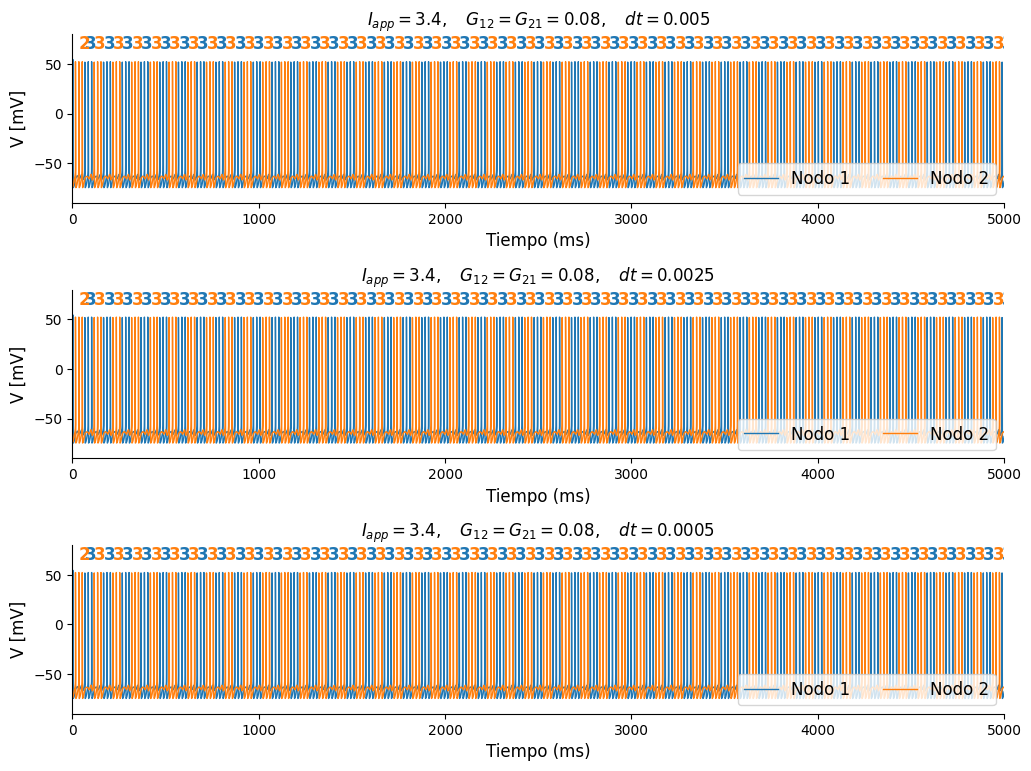

In [13]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.4


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.5

trial 3 estado inicial: [-70, np.float64(0.3859170534584907), np.float64(0.6337939505544279), -65, np.float64(0.3074002708970254), np.float64(0.3101182570955161)]
duración (segundos) de la simulación 46.99792742729187
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


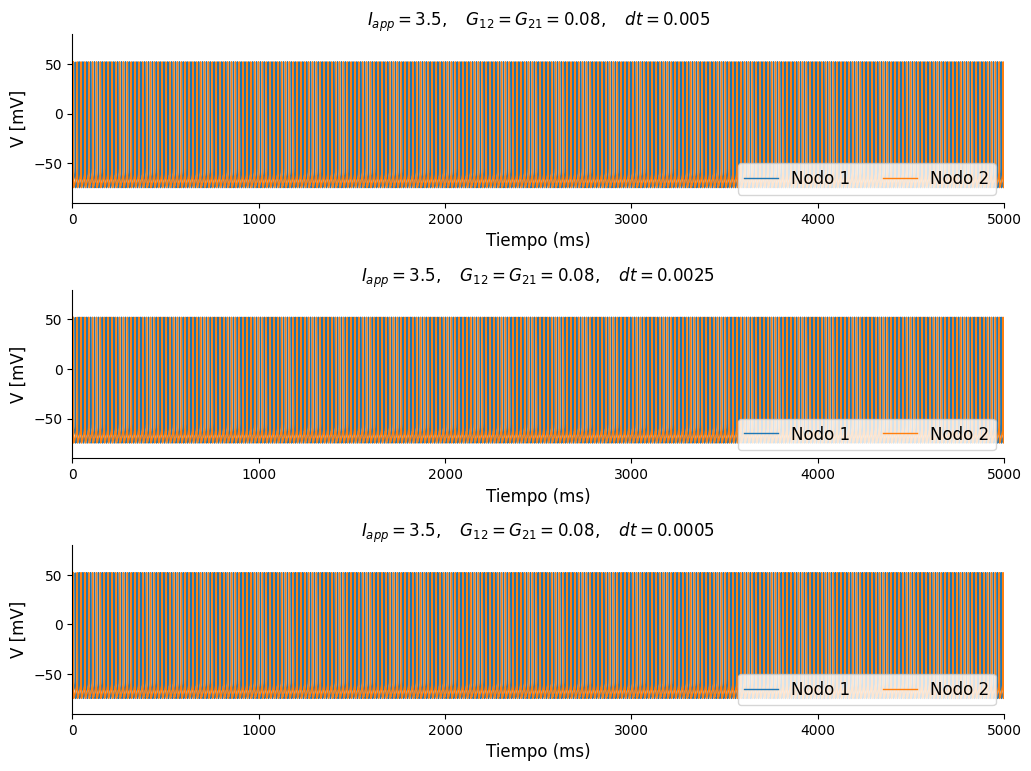

In [51]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.5


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',i+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.6

trial 3 estado inicial: [-70, np.float64(0.9737583104066414), np.float64(0.6489949838559274), -65, np.float64(0.16933517395241648), np.float64(0.5074504661589458)]
duración (segundos) de la simulación 36.29109048843384
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


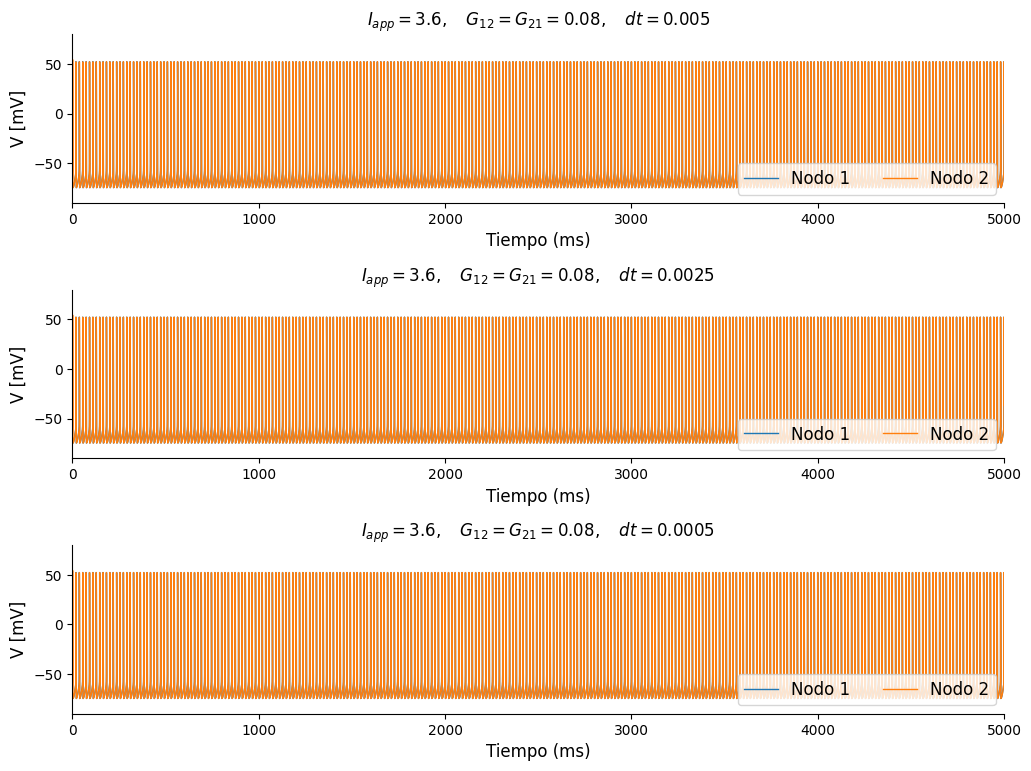

In [14]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.6


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.7

trial 3 estado inicial: [-70, np.float64(0.23471079078215729), np.float64(0.9867623122013071), -65, np.float64(0.9835759300091333), np.float64(0.36693594059190027)]
duración (segundos) de la simulación 32.26009941101074
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


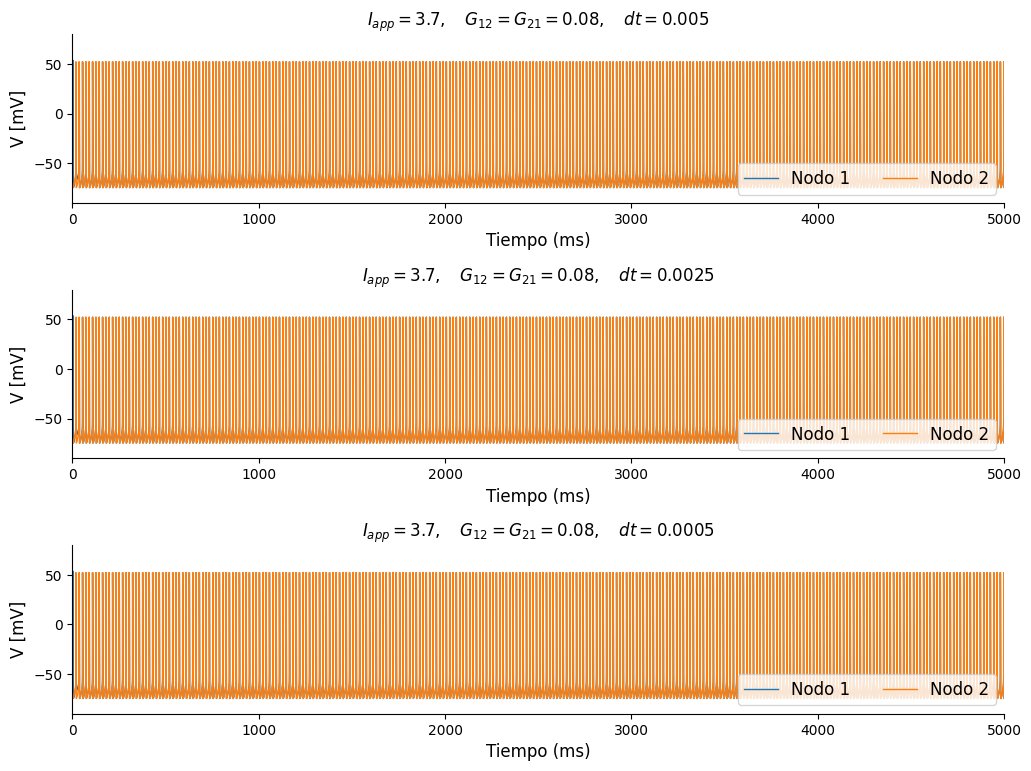

In [15]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.7


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.8

trial 3 estado inicial: [-70, np.float64(0.9448172061486962), np.float64(0.4914837468783323), -65, np.float64(0.0698904375163446), np.float64(0.7571659454714478)]
duración (segundos) de la simulación 36.104575634002686
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


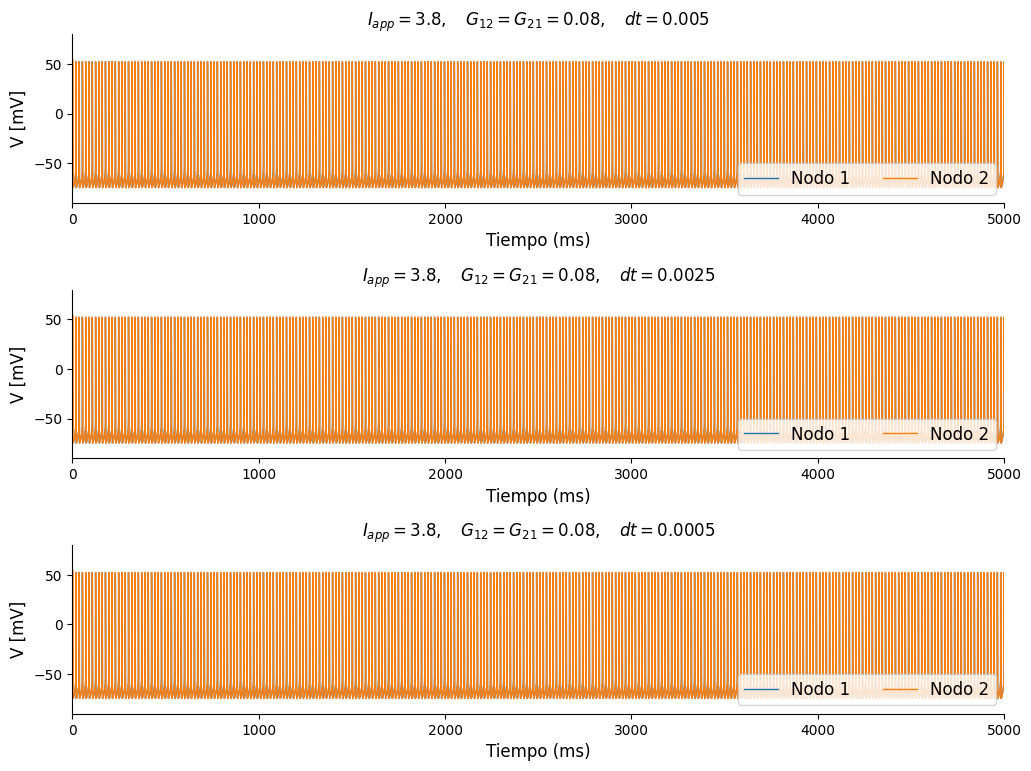

In [16]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.8


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 3.9

trial 3 estado inicial: [-70, np.float64(0.6166513688479962), np.float64(0.8936840486538589), -65, np.float64(0.8940135848146048), np.float64(0.3034821832579385)]
duración (segundos) de la simulación 32.32422614097595


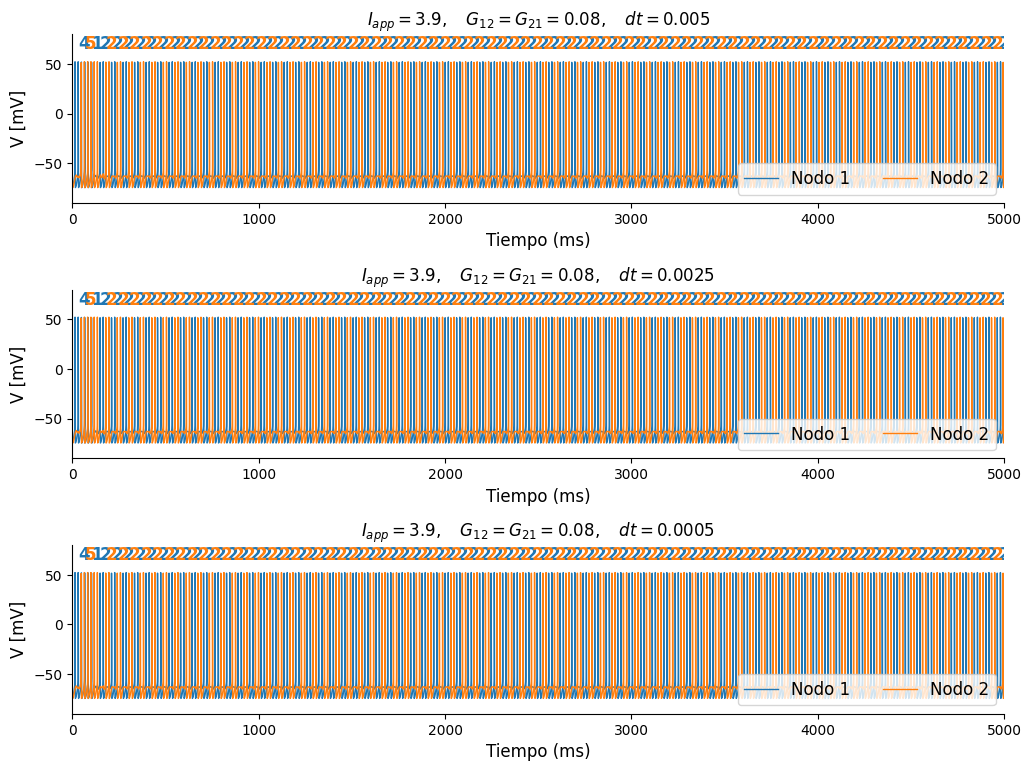

In [17]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.9


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


### Iapp = 4

trial 3 estado inicial: [-70, np.float64(0.7210176230687065), np.float64(0.6717434470294442), -65, np.float64(0.6062828025876453), np.float64(0.40600991553062415)]
duración (segundos) de la simulación 53.11303758621216
corte por umbral!


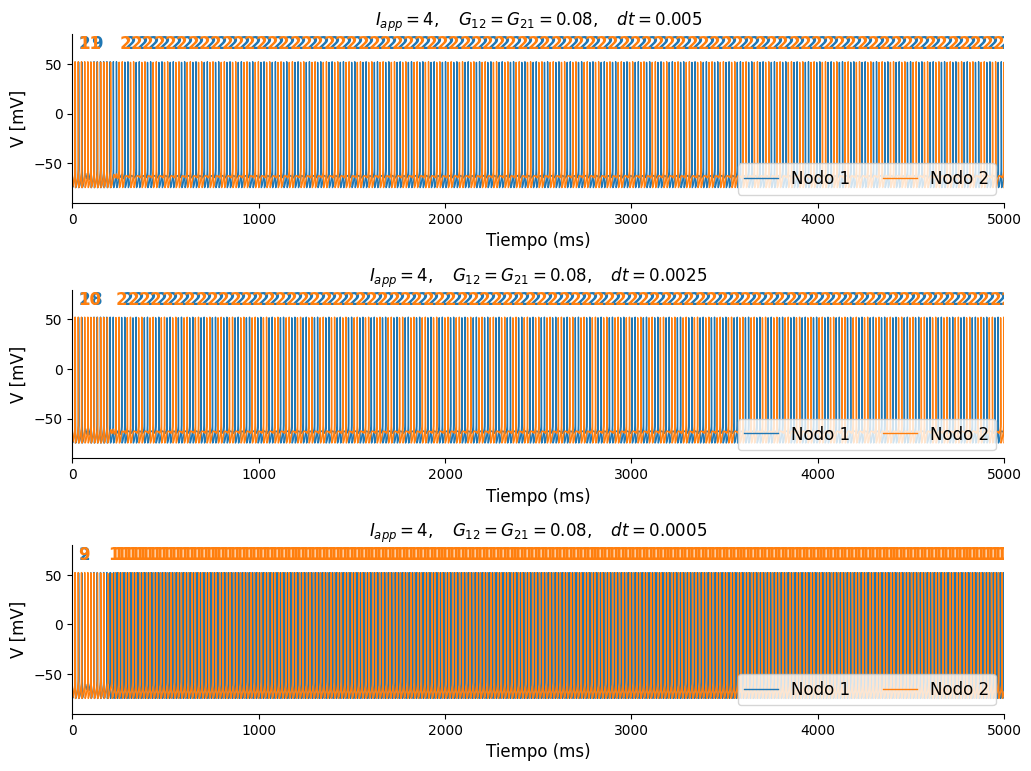

In [ ]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 4


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


# Varío valores de G12,G21

In [19]:
#@title Funciones y parámetros (numba)

import numpy as np
from numba import njit

# =========================
# Funciones auxiliares
# =========================

@njit
def minf(v):
    return 1.0 / (1.0 + np.exp(-(v + 40.0) / 9.0))

@njit
def hinf(v):
    return 1.0 / (1.0 + np.exp((v + 62.0) / 10.0))

@njit
def ninf(v):
    return 1.0 / (1.0 + np.exp(-(v + 53.0) / 16.0))

@njit
def taum(v):
    return 0.3 + 1e-12 * v

@njit
def tauh(v):
    return 1.0 + 11.0 / (1.0 + np.exp((v + 62.0) / 10.0))

@njit
def taun(v):
    return 1.0 + 6.0 / (1.0 + np.exp((v + 53.0) / 16.0))

#expresion equivalente al original [ 0.5 * (1.0 + np.tanh(v / 4.0)) ]
@njit
def sinf(v):
    return 1.0 / (1.0 + np.exp(-v / 2.0))
# =========================
# Parámetros (como floats)
# =========================

C = 1.0
El = -65.0
Ena = 55.0
Ek = -75.0
Gl = 0.025
Gna = 120.0
Gk = 36.0
Ein = -80.0
Gself = 0.08
G12 = 0.08
G21 = 0.08

taurse_i = 0.3
taudec_i = 9.0

alpha = 0.85


# =========================
# Corriente iónica
# =========================

@njit
def Fa(v, n, Iapp):
    return (
        Iapp
        - Gl * (v - El)
        - Gna * (minf(v) ** 3) * (alpha - n) * (v - Ena)
        - Gk * (n ** 4) * (v - Ek)
    )


# =========================
# RK2 (sin crear arrays extra)
# =========================

@njit
def rk2_step_reduced(state, dt, Iapp):
    V, n, S = state

    # k1
    dV1 = (Fa(V, n, Iapp) - Gself * S * (V - Ein)) / C
    dn1 = (ninf(V) - n) / taun(V)
    dS1 = sinf(V) * (1.0 - S) / taurse_i - S / taudec_i

    # estado intermedio
    V2 = V + dt * dV1
    n2 = n + dt * dn1
    S2 = S + dt * dS1

    # k2
    dV2 = (Fa(V2, n2, Iapp) - Gself * S2 * (V2 - Ein)) / C
    dn2 = (ninf(V2) - n2) / taun(V2)
    dS2 = sinf(V2) * (1.0 - S2) / taurse_i - S2 / taudec_i

    # actualización
    state[0] = V + 0.5 * dt * (dV1 + dV2)
    state[1] = n + 0.5 * dt * (dn1 + dn2)
    state[2] = S + 0.5 * dt * (dS1 + dS2)

    return state


# =========================
# Red de 2 nodos
# =========================
@njit
def rk2_step_net(state, dt, Iapp, G12, G21):
    V1, n1, S1, V2, n2, S2 = state

    # k1
    dV1 = (Fa(V1, n1, Iapp) - G21 * S2 * (V1 - Ein)) / C
    dn1 = (ninf(V1) - n1) / taun(V1)
    dS1 = sinf(V1) * (1.0 - S1) / taurse_i - S1 / taudec_i

    dV2 = (Fa(V2, n2, Iapp) - G12 * S1 * (V2 - Ein)) / C
    dn2 = (ninf(V2) - n2) / taun(V2)
    dS2 = sinf(V2) * (1.0 - S2) / taurse_i - S2 / taudec_i

    # estado intermedio
    V1_ = V1 + dt * dV1
    n1_ = n1 + dt * dn1
    S1_ = S1 + dt * dS1

    V2_ = V2 + dt * dV2
    n2_ = n2 + dt * dn2
    S2_ = S2 + dt * dS2

    # k2
    dV1_ = (Fa(V1_, n1_, Iapp) - G21 * S2_ * (V1_ - Ein)) / C
    dn1_ = (ninf(V1_) - n1_) / taun(V1_)
    dS1_ = sinf(V1_) * (1.0 - S1_) / taurse_i - S1_ / taudec_i

    dV2_ = (Fa(V2_, n2_, Iapp) - G12 * S1_ * (V2_ - Ein)) / C
    dn2_ = (ninf(V2_) - n2_) / taun(V2_)
    dS2_ = sinf(V2_) * (1.0 - S2_) / taurse_i - S2_ / taudec_i

    # actualización
    state[0] = V1 + 0.5 * dt * (dV1 + dV1_)
    state[1] = n1 + 0.5 * dt * (dn1 + dn1_)
    state[2] = S1 + 0.5 * dt * (dS1 + dS1_)

    state[3] = V2 + 0.5 * dt * (dV2 + dV2_)
    state[4] = n2 + 0.5 * dt * (dn2 + dn2_)
    state[5] = S2 + 0.5 * dt * (dS2 + dS2_)

    return state

# ========================
# Función de paralelizacion
# =========================

from numba import prange

@njit(parallel=True)
def simulate_all(Y_redes, V1_0,n1_0,s1_0,V2_0,n2_0,s2_0, dt, Iapp, G12, G21):
    nets_num, N, _ = Y_redes.shape

    for j in prange(nets_num):
        Y_redes[j,0,0] = V1_0[j]
        Y_redes[j,0,1] = n1_0[j]
        Y_redes[j,0,2] = s1_0[j]
        Y_redes[j,0,3] = V2_0[j]
        Y_redes[j,0,4] = n2_0[j]
        Y_redes[j,0,5] = s2_0[j]

        state = np.empty(6)
        state[:] = Y_redes[j,0,:]

        for i in range(1, N):
            rk2_step_net(state, dt, Iapp, G12, G21)
            Y_redes[j,i,:] = state

# =====================================================
# Función de Paralelizacion Mínima (solo guardo V1 y V2)
# =====================================================
@njit(parallel=True)
def simulate_all_min(Y_redes, V1_0,n1_0,s1_0,V2_0,n2_0,s2_0, dt, Iapp, G12, G21):
    nets_num, N, _ = Y_redes.shape

    for j in prange(nets_num):
        state = np.empty(6)
        state[0] = V1_0[j]
        state[1] = n1_0[j]
        state[2] = s1_0[j]
        state[3] = V2_0[j]
        state[4] = n2_0[j]
        state[5] = s2_0[j]
        # guardar estado inicial
        Y_redes[j,0,0] = state[0]
        Y_redes[j,0,1] = state[3]
        #integrar
        for i in range(1, N):
            rk2_step_net(state, dt, Iapp, G21, G12)
            Y_redes[j,i,0] = state[0]
            Y_redes[j,i,1] = state[3]

In [20]:
g_vals = np.linspace(0.0, 0.25, 21)

results = []

for g in g_vals:
    Y_redes = np.empty((nets_num, N, 2))

    simulate_all_min(
        Y_redes,
        V1_0, n1_0, s1_0,
        V2_0, n2_0, s2_0,
        dt, Iapp, g, g
    )

    results.append(Y_redes.copy())


## Vario G21, con Iapp = 2.6

trial 3 estado inicial: [-70, np.float64(0.7704223274965388), np.float64(0.062168238382753205), -65, np.float64(0.642455736173446), np.float64(0.7673008634321297)]
duración (segundos) de la simulación 70.66915655136108
corte por umbral!
corte por umbral!
corte por umbral!


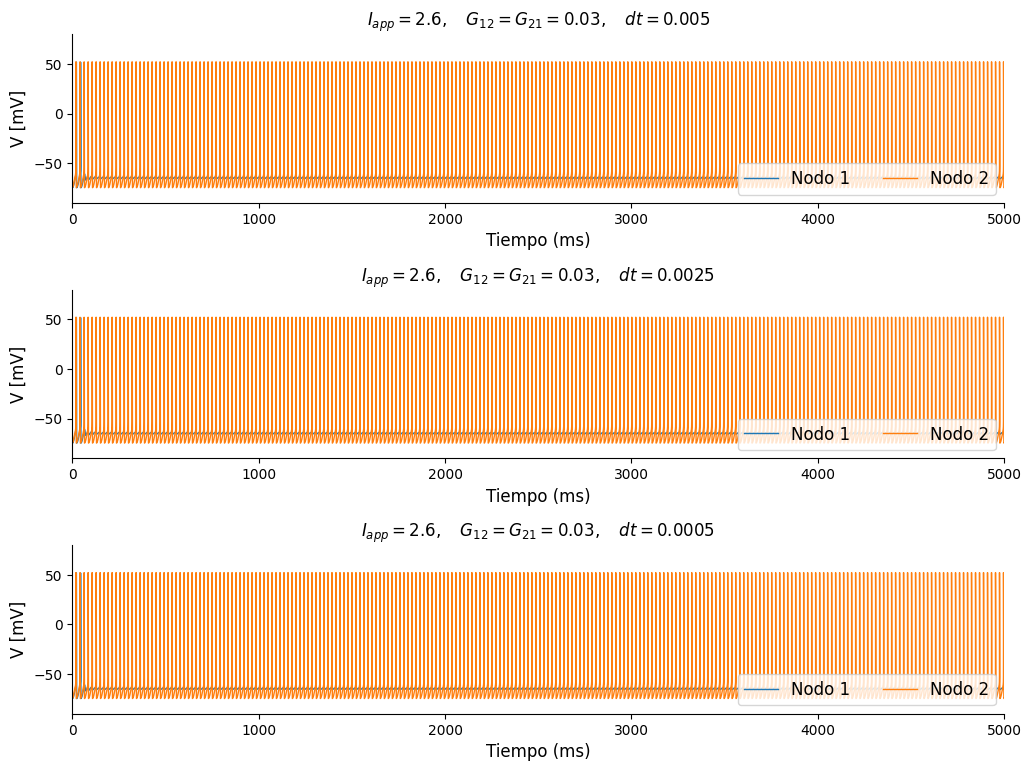

In [32]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.6
G21 = 0.03
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.6947642766324098), np.float64(0.6225578173377279), -65, np.float64(0.35929122684966475), np.float64(0.7510648628917711)]
duración (segundos) de la simulación 56.878416299819946
corte por umbral!
corte por umbral!
corte por umbral!


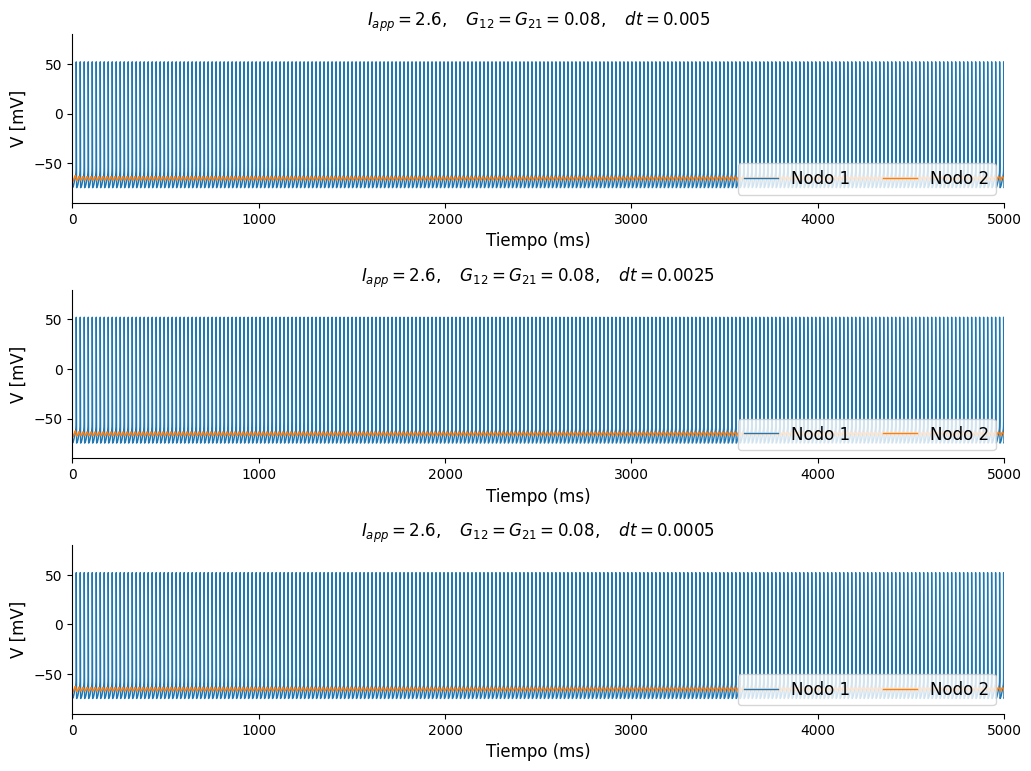

In [33]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.6
G21 = 0.08
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.37451626182752984), np.float64(0.42763831544336695), -65, np.float64(0.5681056173951979), np.float64(0.23415099492266633)]
duración (segundos) de la simulación 49.09554362297058
corte por umbral!
corte por umbral!
corte por umbral!


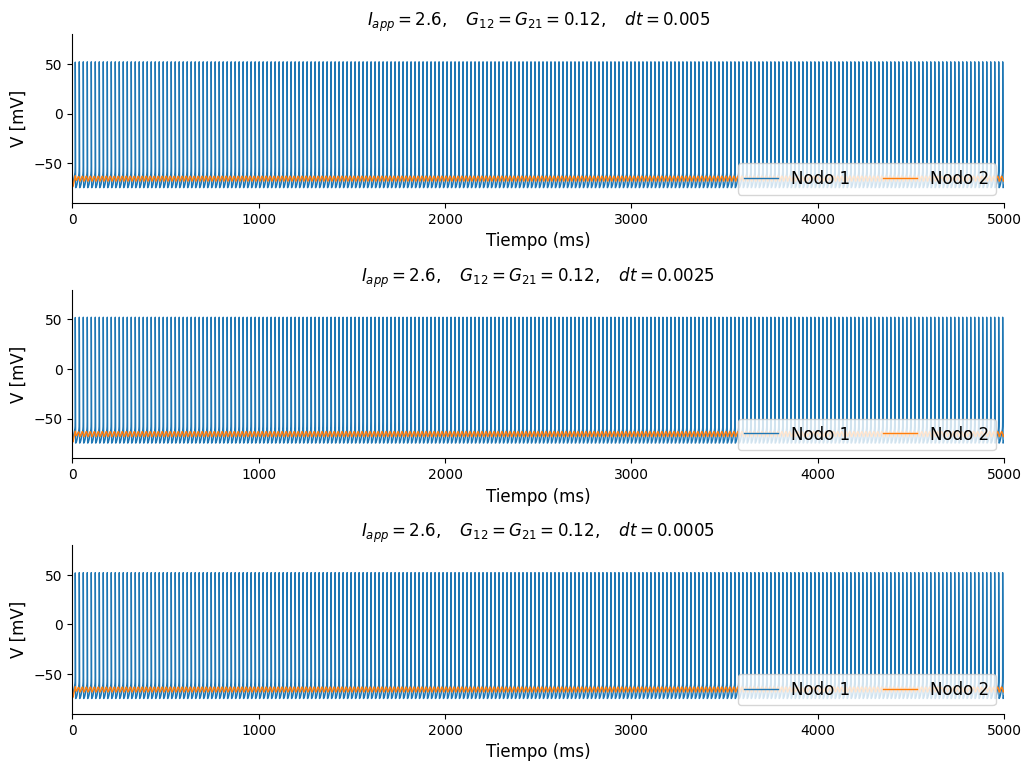

In [34]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.6
G21 = 0.12
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.814542356011403), np.float64(0.359406358751705), -65, np.float64(0.8546576662319528), np.float64(0.5520506185995072)]
duración (segundos) de la simulación 68.12777328491211
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


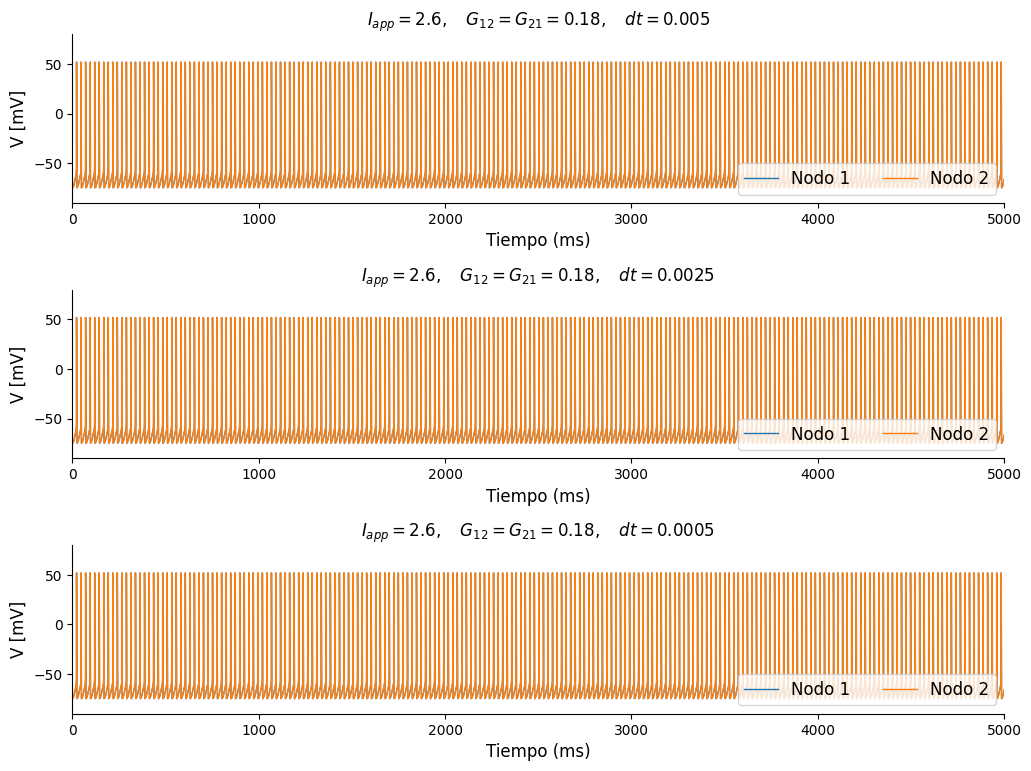

In [35]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.6
G21 = 0.18
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.7879954598583336), np.float64(0.7285998862097369), -65, np.float64(0.5483662116325257), np.float64(0.30060488936927143)]
duración (segundos) de la simulación 52.591495990753174
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


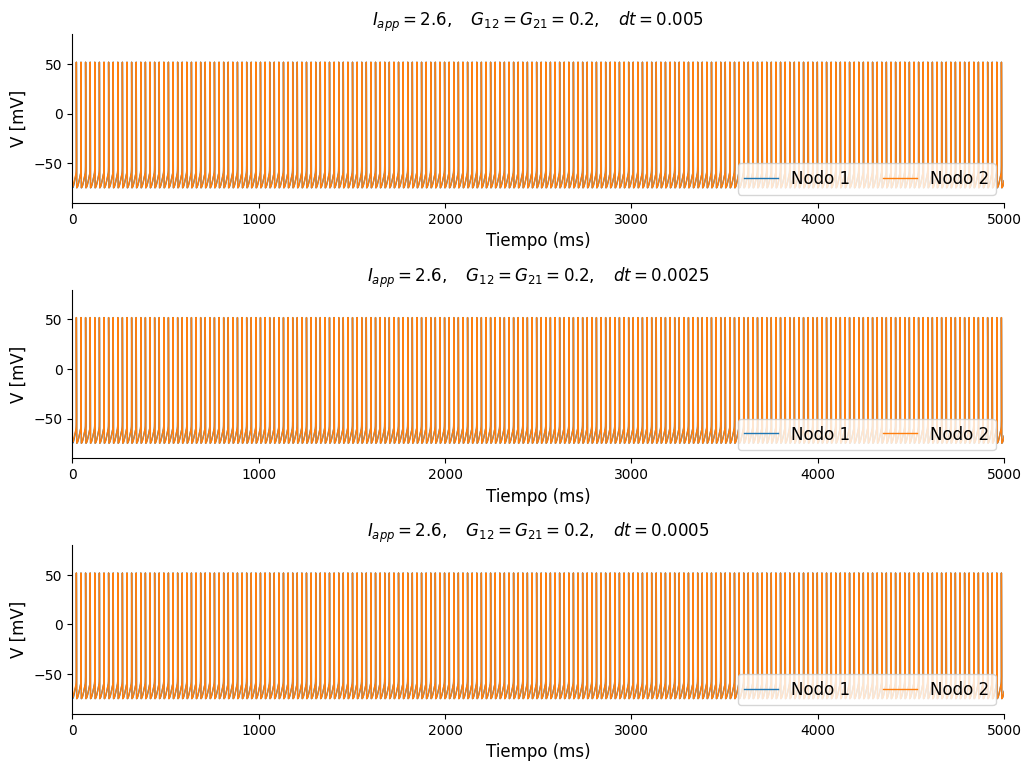

In [36]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 2.6
G21 = 0.20
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


## Vario G21 con Iapp = 3.1

trial 3 estado inicial: [-70, np.float64(0.3679938919180734), np.float64(0.10893208472453753), -65, np.float64(0.6516660205022479), np.float64(0.3287261834882993)]
duración (segundos) de la simulación 95.17715716362
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


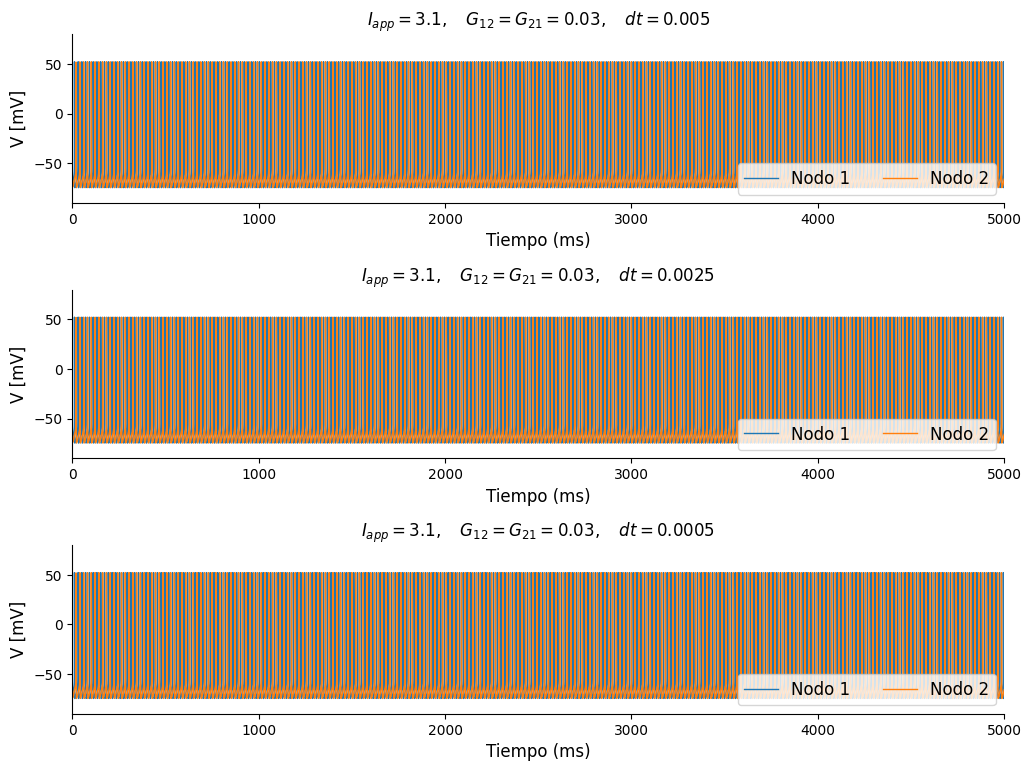

In [22]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.1
G21 = 0.03
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.9267258269967479), np.float64(0.1927815368034812), -65, np.float64(0.4211374107411062), np.float64(0.6934004616331578)]
duración (segundos) de la simulación 66.09658527374268
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


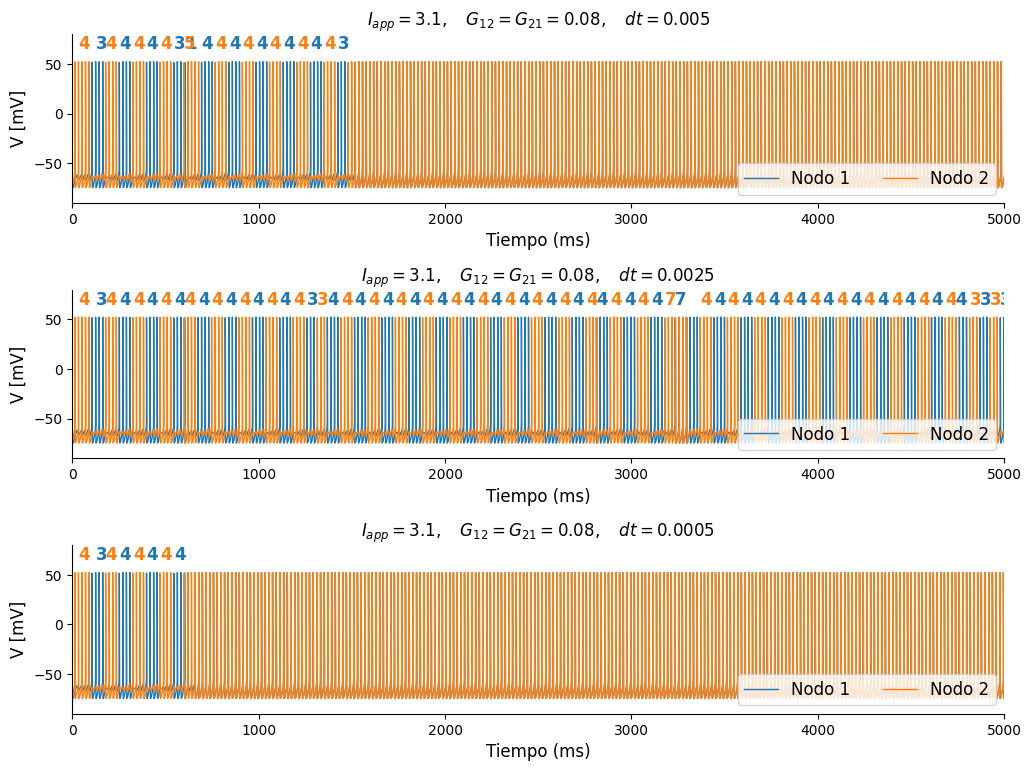

In [23]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.1
G21 = 0.08
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.7609469359586711), np.float64(0.97872763967421), -65, np.float64(0.23052615392490616), np.float64(0.2663573848567077)]
duración (segundos) de la simulación 52.60902214050293


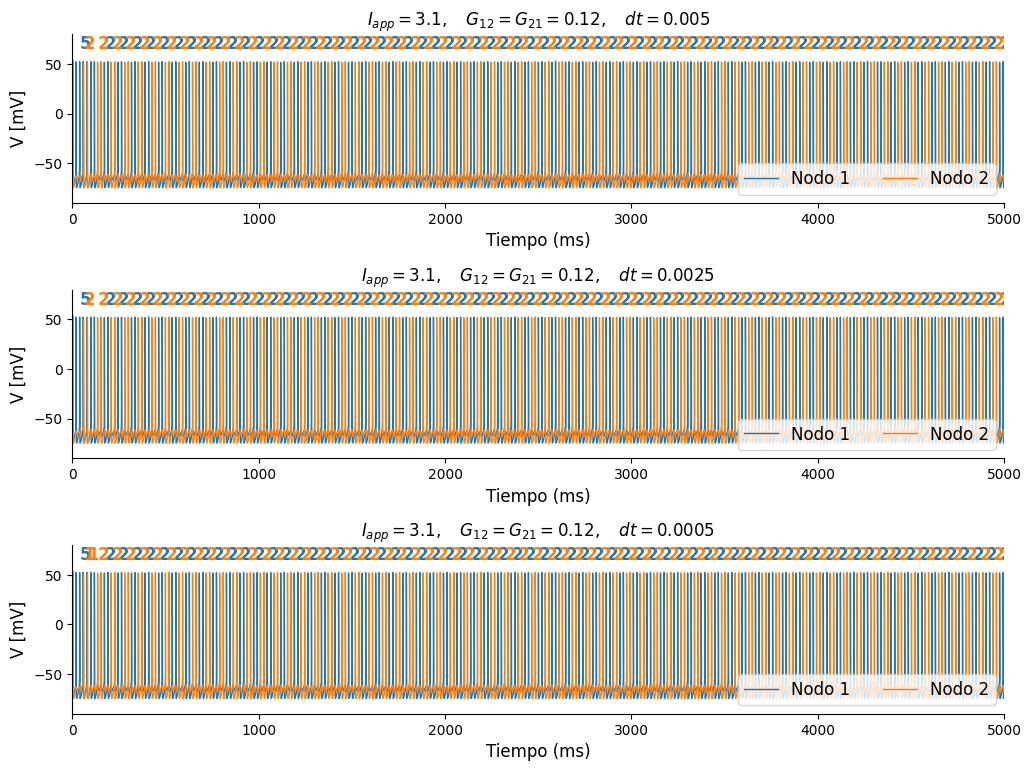

In [24]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.1
G21 = 0.12
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.4532076706823378), np.float64(0.27812337848660174), -65, np.float64(0.33000023525755096), np.float64(0.3428987832103133)]
duración (segundos) de la simulación 52.191811084747314
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


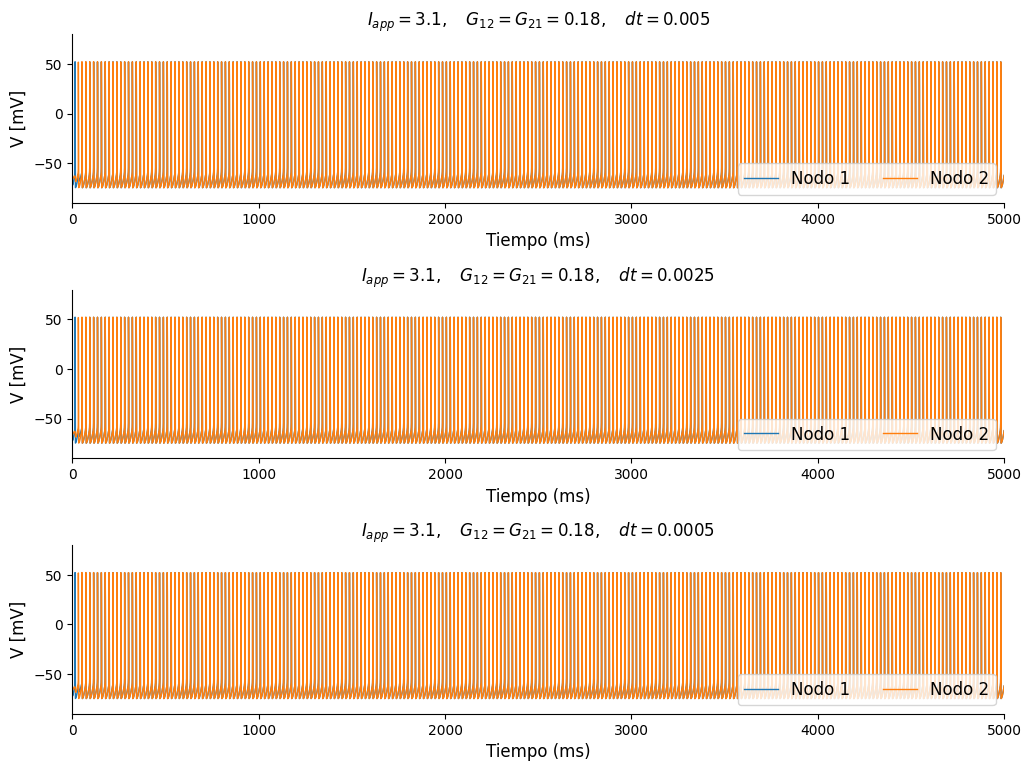

In [25]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.1
G21 = 0.18
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.31146182807590905), np.float64(0.6697824665662236), -65, np.float64(0.4161251135216214), np.float64(0.7066480134145106)]
duración (segundos) de la simulación 49.67730474472046
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


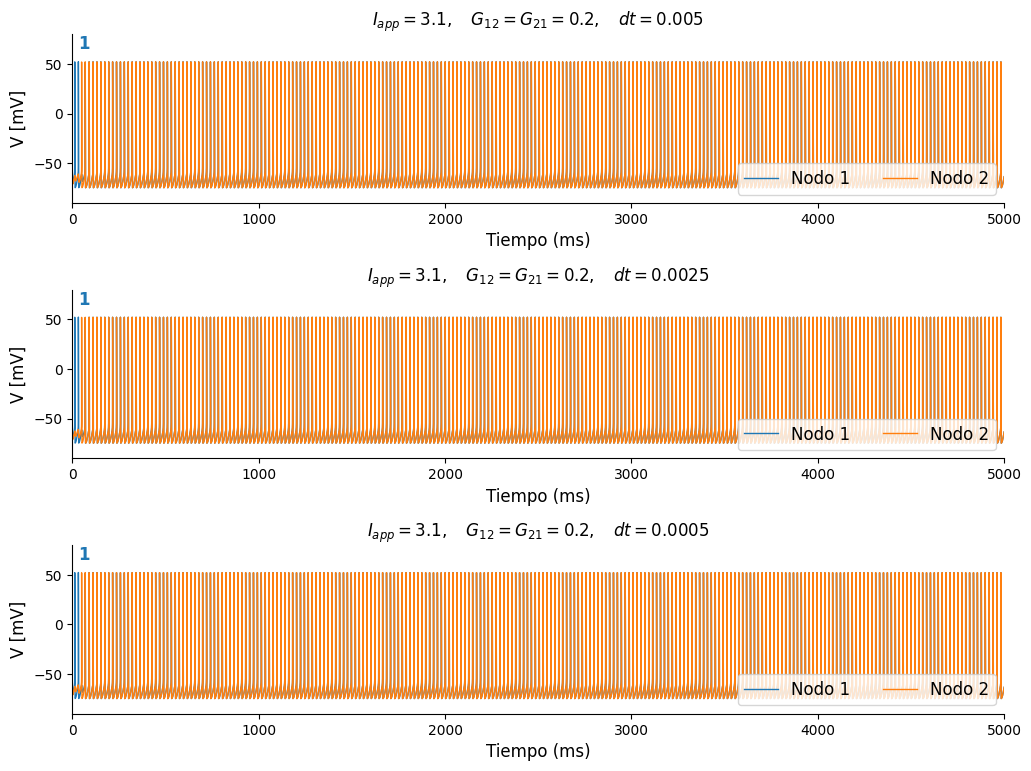

In [26]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.1
G21 = 0.20
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


## Vario G21, con Iapp = 3.4

trial 3 estado inicial: [-70, np.float64(0.07549760454331356), np.float64(0.03851552360485688), -65, np.float64(0.8060716092618073), np.float64(0.2618174467703125)]
duración (segundos) de la simulación 55.194676876068115


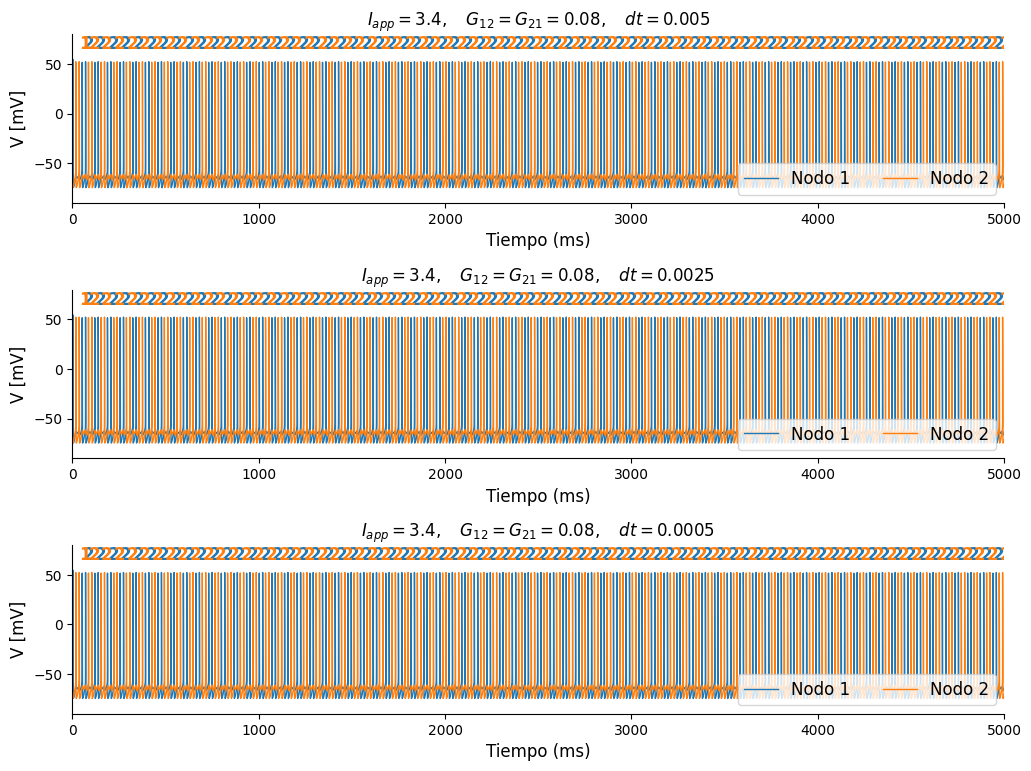

In [30]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.4
G21 = 0.08
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.7137334701689682), np.float64(0.7121223293539871), -65, np.float64(0.7346367953986238), np.float64(0.754268895223367)]
duración (segundos) de la simulación 65.64381146430969
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


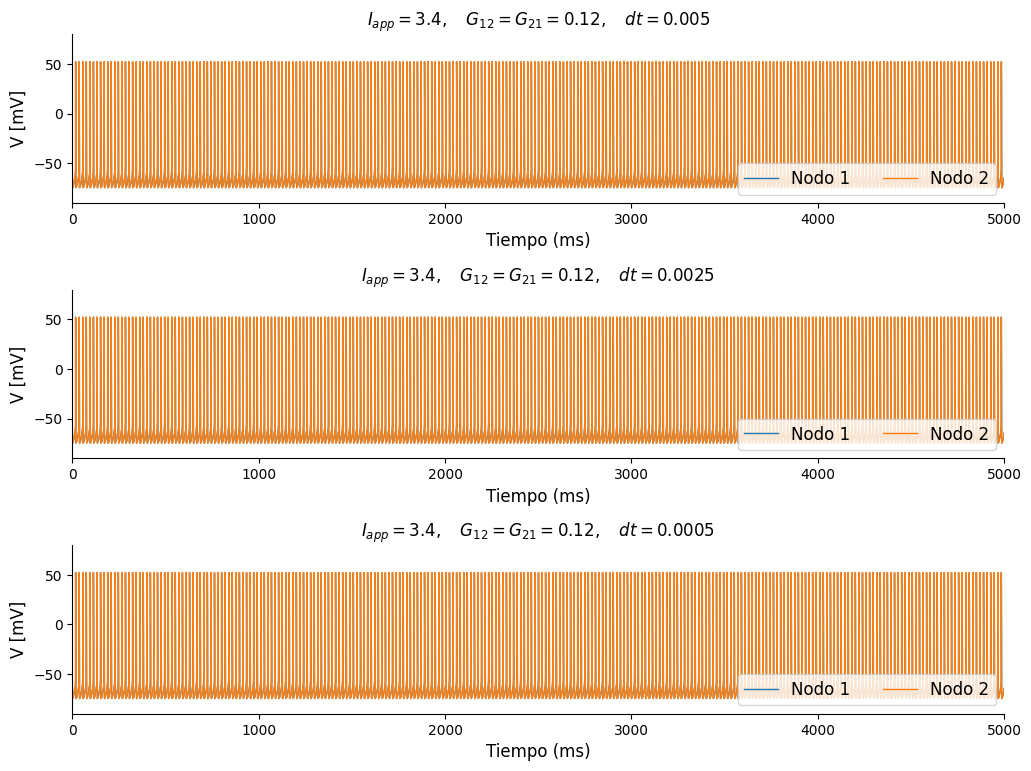

In [29]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.4
G21 = 0.12
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.9328614469832494), np.float64(0.3980591153933287), -65, np.float64(0.4283725660514316), np.float64(0.680125013059911)]
duración (segundos) de la simulación 66.73110628128052


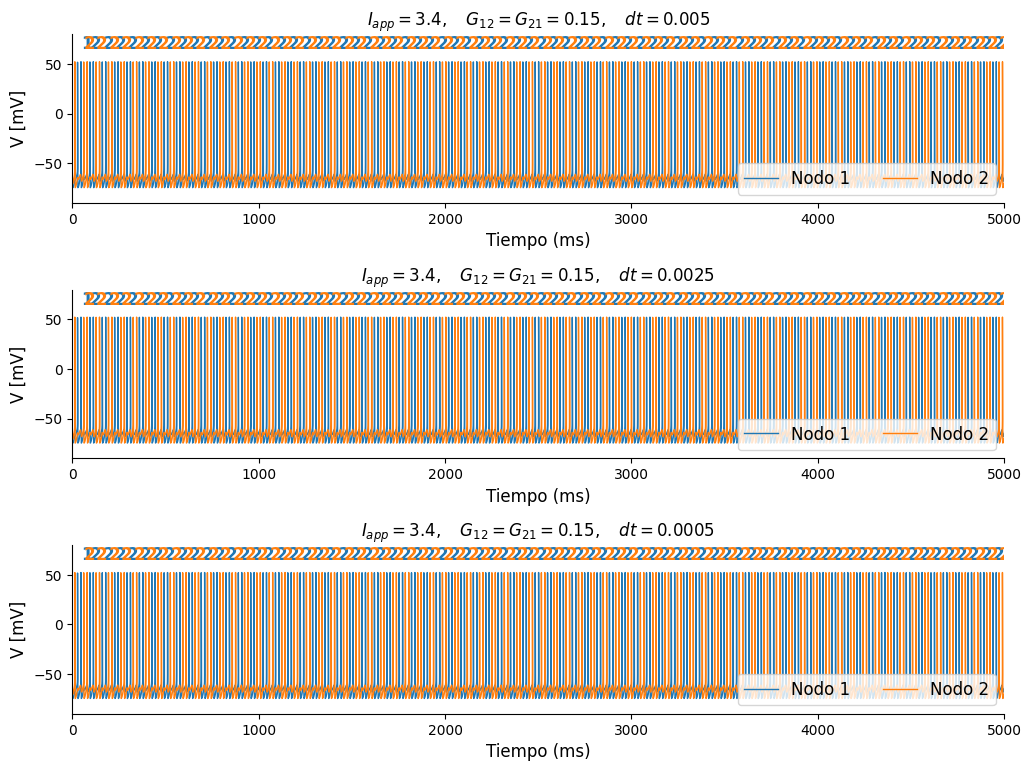

In [28]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.4
G21 = 0.15
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.18553564371966114), np.float64(0.9712793174417474), -65, np.float64(0.8137421750311185), np.float64(0.3805348472527934)]
duración (segundos) de la simulación 60.11809253692627
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


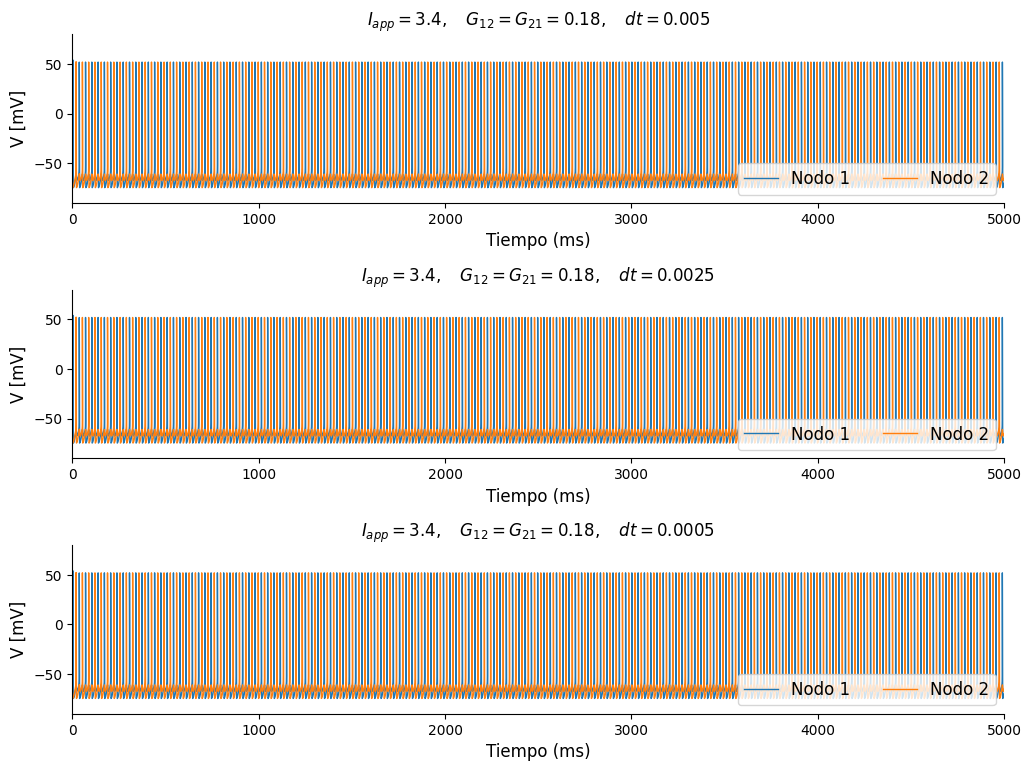

In [31]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.4
G21 = 0.18
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


trial 3 estado inicial: [-70, np.float64(0.5360751951340008), np.float64(0.08882806428012402), -65, np.float64(0.10880716798268597), np.float64(0.2199686836795085)]
duración (segundos) de la simulación 67.2961597442627
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!
corte por umbral!


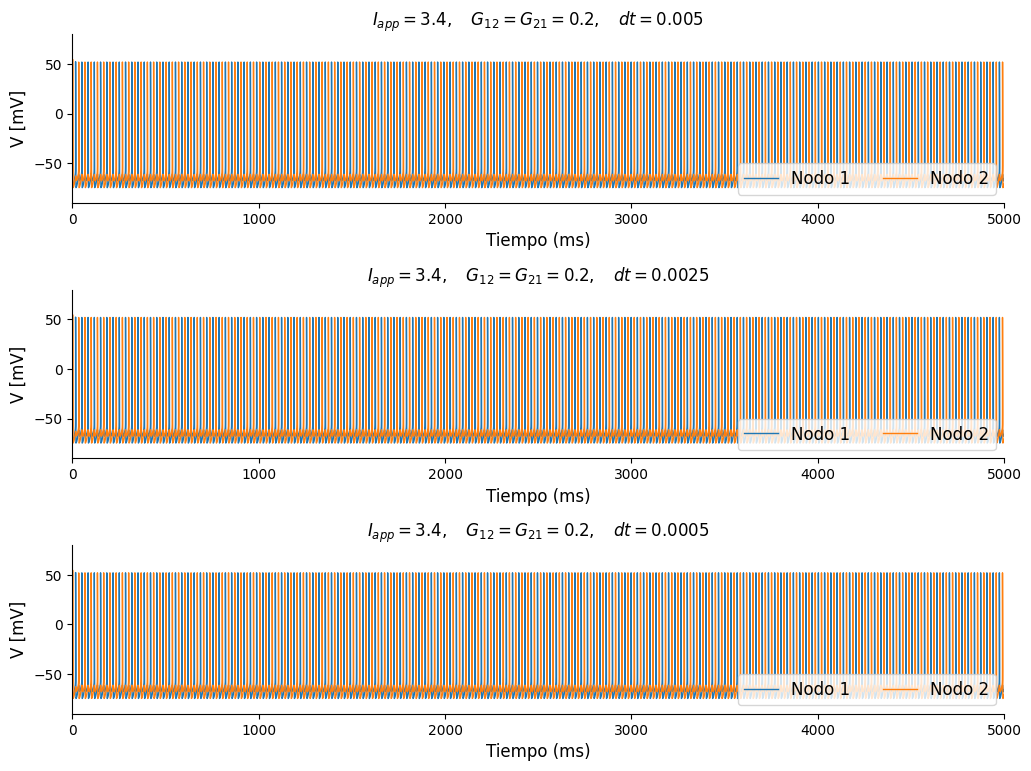

In [27]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.4
G21 = 0.20
G12 = G21


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp, G12, G21)

#end = time.time()
#print('duración (segundos) de la simulación',end - start)

#print('====================')
#print('condiciones iniciales')
#print('====================')
#for i in range(nets_num):
#  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

print('trial',k+1,'estado inicial:',[V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]])

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp, G12, G21)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp, G12, G21)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp, G12, G21)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)-----------------------------------------------------------------------------------------------------------

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#


# Funciona por separado

In [4]:
#@title integración de la red

"""parametros temporales"""
t0 = 0.0
Tmax = 10000.0
dt = 0.005
t = np.arange(t0,Tmax+dt,dt)
N = len(t)

"""Iapp"""
Iapp = 3.01


""""""
nets_num = 7
#condiciones iniciales para cada red
V1_0 = [-90,-80,-70,-50,-40,-30,10]
n1_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s1_0 = np.random.rand(nets_num)#0.5*np.ones(nets_num)
V2_0 = [-65,-65,-65,-65,-65,-65,-65]
n2_0 = np.random.rand(nets_num)#0.2*np.ones(nets_num)
s2_0 = np.random.rand(nets_num)#np.zeros(nets_num)

"""solo guardo V1 y V2"""
Y_redes = np.empty((nets_num, N, 2))
start = time.time()

simulate_all_min(Y_redes, V1_0, n1_0, s1_0, V2_0, n2_0, s2_0,dt, Iapp)

end = time.time()
print('duración (segundos) de la simulación',end - start)

print('====================')
print('condiciones iniciales')
print('====================')
for i in range(nets_num):
  print('trial',i+1,'estado inicial:',[V1_0[i],n1_0[i],s1_0[i],V2_0[i],n2_0[i],s2_0[i]])


duración (segundos) de la simulación 3.5850374698638916
condiciones iniciales
trial 1 estado inicial: [-90, np.float64(0.2796175825175705), np.float64(0.48764543136574723), -65, np.float64(0.5349452382987099), np.float64(0.7490380656146792)]
trial 2 estado inicial: [-80, np.float64(0.668637009359857), np.float64(0.0013739550400734268), -65, np.float64(0.6853116491982261), np.float64(0.7646448907444464)]
trial 3 estado inicial: [-70, np.float64(0.2613193045981469), np.float64(0.9838398342556193), -65, np.float64(0.4484272252147491), np.float64(0.2804816491701765)]
trial 4 estado inicial: [-50, np.float64(0.9138896857413431), np.float64(0.721583457441657), -65, np.float64(0.6515278606824486), np.float64(0.45487018290120396)]
trial 5 estado inicial: [-40, np.float64(0.6851686512730157), np.float64(0.27616511318888093), -65, np.float64(0.32046612339111114), np.float64(0.24686157792889774)]
trial 6 estado inicial: [-30, np.float64(0.36897282719625135), np.float64(0.693524843662258), -65, np

In [ ]:
#@title resimulacion con distintos dt-------------------------------------------------------------------------------------------------------------------------------------------
k = 2

start = time.time()
"""copio los valores antes usados"""
dt_p = np.copy(dt)
t_p = np.arange(t0,Tmax+dt_p,dt_p)
N_p = len(t_p)


"""resimulacion con valores previos"""
Y_red_p = np.empty((N_p, 6), dtype=np.float64)
Y_red_p[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_p[0,:]
for i in range(1, N_p):
    rk2_step_net(state, dt_p, Iapp)   # modifica state
    Y_red_p[i,:] = state


# ==============================
# simulacion con mayor presicion (1)
# ==============================
dt_r = np.copy(dt)*0.5               # nuevo paso de integracion
t_r = np.arange(t0,Tmax+dt_r,dt_r)
N_r = len(t_r)


"""simulacion con valores previos"""
Y_red_r = np.empty((N_r, 6), dtype=np.float64)
Y_red_r[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_r[0,:]
for i in range(1, N_r):
    rk2_step_net(state, dt_r, Iapp)   # modifica state
    Y_red_r[i,:] = state




# ==============================
# simulacion con mayor presicion (2)
# ==============================
dt_q = np.copy(dt)*0.1              # nuevo paso de integracion
t_q = np.arange(t0,Tmax+dt_q,dt_q)
N_q = len(t_q)


"""simulacion con valores previos"""
Y_red_q = np.empty((N_q, 6), dtype=np.float64)
Y_red_q[0,:] = [V1_0[k],n1_0[k],s1_0[k],V2_0[k],n2_0[k],s2_0[k]]

#integracion
state = np.empty(6)
state[:] = Y_red_q[0,:]
for i in range(1, N_q):
    rk2_step_net(state, dt_q, Iapp)   # modifica state
    Y_red_q[i,:] = state

end = time.time()
print('duración (segundos) de la simulación',end - start)


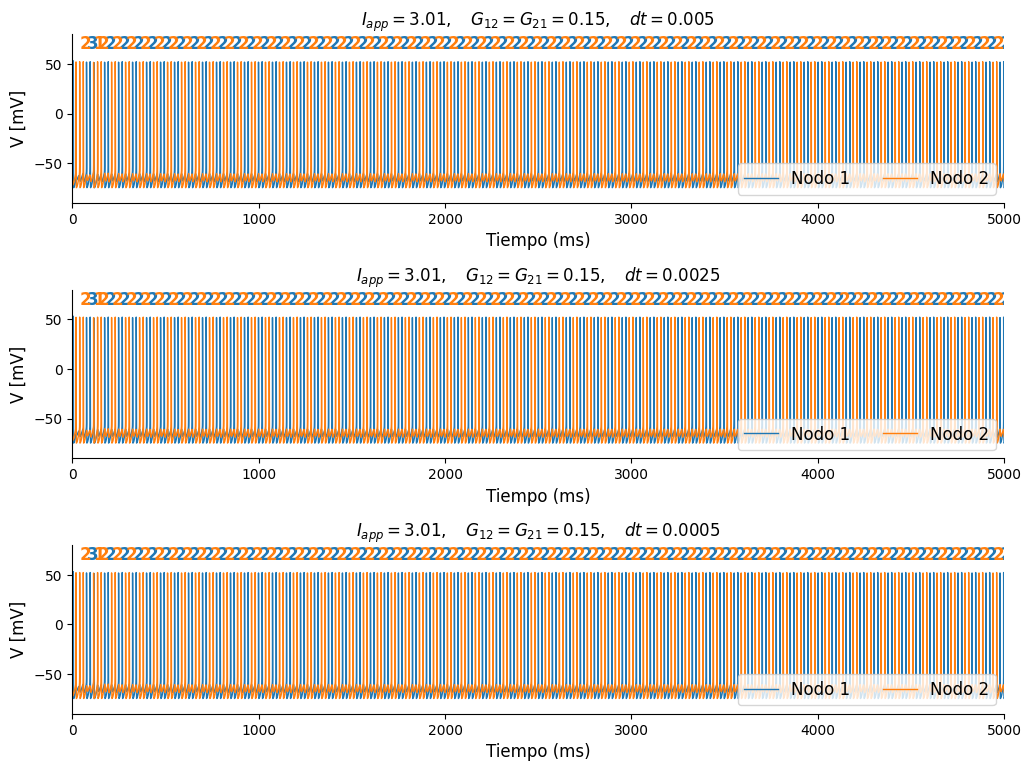

In [6]:
#@title plot del transitorio "filtrado" (series temporales, plot 2d, histograma)

# filtrado de la primer simulacion
sig_1_p = Y_red_p[:,0]
count_1_p, max_1_p, max_init_1_p = cod_tran(sig_1_p)

sig_2_p = Y_red_p[:,3]
count_2_p, max_2_p, max_init_2_p = cod_tran(sig_2_p)

# filtrado de la segunda simulacion
sig_1_r = Y_red_r[:,0]
count_1_r, max_1_r, max_init_1_r = cod_tran(sig_1_r)

sig_2_r = Y_red_r[:,3]
count_2_r, max_2_r, max_init_2_r = cod_tran(sig_2_r)

# filtrado de la tercer simulacion
sig_1_q = Y_red_q[:,0]
count_1_q, max_1_q, max_init_1_q = cod_tran(sig_1_q)

sig_2_q = Y_red_q[:,3]
count_2_q, max_2_q, max_init_2_q = cod_tran(sig_2_q)


# ------------ Series Temporales  -----------
my_dpi = 96
fig_series = True
if fig_series is True:
  fig, ax = plt.subplots(3,1,figsize=(1000/my_dpi,250*3/my_dpi))

  # primer plot
  ax[0].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_p), fontsize=12)
  # ---- primer nodo ---
  ax[0].plot(t_p,sig_1_p, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_p)-1):
    ax[0].text(t_p[max_init_1_p[i]],65,'%s'%(count_1_p[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[0].plot(t_p,sig_2_p,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_p)-1):
    ax[0].text(t_p[max_init_2_p[i]],65,'%s'%(count_2_p[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  # segundo plot
  ax[1].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_r), fontsize=12)
  # ---- primer nodo ---
  ax[1].plot(t_r,sig_1_r, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_r)-1):
    ax[1].text(t_r[max_init_1_r[i]],65,'%s'%(count_1_r[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[1].plot(t_r,sig_2_r,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_r)-1):
    ax[1].text(t_r[max_init_2_r[i]],65,'%s'%(count_2_r[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')

  # tercer plot
  ax[2].set_title(r'$I_{app} = %s,\quad G_{12}=G_{21}=%s,\quad dt = %s$'%(Iapp,G12,dt_q), fontsize=12)
  # ---- primer nodo ---
  ax[2].plot(t_q,sig_1_q, linewidth=1, label = 'Nodo 1')
  for i in range(len(max_init_1_q)-1):
    ax[2].text(t_q[max_init_1_q[i]],65,'%s'%(count_1_q[i]),clip_on=True, color = 'tab:blue', fontsize=12,fontweight='bold')
  # ---- segundo nodo ---
  ax[2].plot(t_q,sig_2_q,linewidth=1, label = 'Nodo 2')
  for i in range(len(max_init_2_q)-1):
    ax[2].text(t_q[max_init_2_q[i]],65,'%s'%(count_2_q[i]),clip_on=True, color = 'tab:orange', fontsize=12,fontweight='bold')


  for i in range(3):
    ax[i].legend(fontsize = 12, loc='lower right', frameon = True, ncols = 2)
    ax[i].set_xlabel('Tiempo (ms)', fontsize=12)
    ax[i].set_ylabel('V [mV]', fontsize=12)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlim(0,5000)
    ax[i].set_ylim(-90,80)
  #
  plt.tight_layout()

  plt.show()
  plt.close()
#